In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from concept_abstraction.plotting import *
from concept_abstraction.utils import *

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [4]:
style_size = 'paper'

## Perfect Concepts

In [5]:
training_times = {
    'cyclic_4':10_000,
    'cyclic_16':10_000,
    'tree_7': 25_000, 
    'tree_31': 25_000,
    'cart_pole': 1_000_000,
    'mini_grid': 250_000,
    'mimic': 250_000,
    'pong': 2_000_000,
    'boxing': 2_000_000,
}

In [6]:
number_concepts = [1,2,3,4,5,6,8,10,15,20,25,30,35,40,45,50,60,70,80]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31","cart_pole","mini_grid","mimic","pong","boxing"]

random_results = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
random_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
greedy_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
greedy_iterative_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
basic_comparison = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]

for i,n in enumerate(number_concepts):
    for j,e in enumerate(environments):
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'num_concepts_selected': n, 'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_two_stage': False, 'run_imperfect': False, 'run_intervention': False})
        
        if len(matching_params) == 0 or 'basic_comparison' not in matching_params[0]:
            res = [0,0,0,0,0]
            all_vals = [res]
        else:
            print(e,n,len(matching_params))
            all_vals = []
            for m in matching_params:
                if e in ["cart_pole","mini_grid","pong","boxing"] or (e == "mimic" and 'decision_tree' not in m['basic_comparison']):
                    res = [
                        m['basic_comparison']['random']['reward'],
                        m['basic_comparison']['random_selection']['reward'],
                        m['basic_comparison']['greedy']['reward'],
                        m['basic_comparison']['multiple']['reward'],
                        m['basic_comparison']['lp']['reward'],
                    ]
                elif e == "mimic" and 'decision_tree' in m['basic_comparison']:
                    res = [
                        m['basic_comparison']['random']['reward'],
                        m['basic_comparison']['decision_tree']['reward'],
                        m['basic_comparison']['greedy']['reward'],
                        m['basic_comparison']['multiple']['reward'],
                        m['basic_comparison']['lp']['reward'],
                    ]
                else:
                    res = [
                        m['basic_comparison']['random']['reward'],
                        m['basic_comparison']['random_selection']['reward'],
                        m['basic_comparison']['greedy']['reward'],
                        m['basic_comparison']['greedy_iterative']['reward'],
                        m['basic_comparison']['lp']['reward'],
                    ]
                all_vals.append(res)
        random_results[j][i] = [i[0] for i in all_vals]
        random_selection[j][i] = [i[1] for i in all_vals]
        greedy_selection[j][i] = [i[2] for i in all_vals]
        greedy_iterative_selection[j][i] = [i[3] for i in all_vals]
        lp_selection[j][i] = [i[4] for i in all_vals]
        basic_comparison[j][i] = [m['ground_truth']['reward'] for m in matching_params]


cyclic_4 1 1
tree_7 1 1
tree_31 1 1
cyclic_4 2 1
cyclic_16 2 1
tree_7 2 1
tree_31 2 1
cyclic_4 3 1
tree_7 3 1
tree_31 3 1
cyclic_16 4 1
tree_7 4 1
tree_31 4 1
tree_31 5 1
cart_pole 5 3
cyclic_16 6 1
cyclic_16 8 1
cart_pole 10 3
cart_pole 15 3
mini_grid 20 3
mimic 20 15
pong 20 1
boxing 20 1
mini_grid 30 3
mimic 30 3
pong 30 1
boxing 30 1
mini_grid 40 3
mimic 40 15
pong 40 1
mimic 50 3
mimic 60 15
mimic 80 15


/tmp/ipykernel_2336316/534127209.py:29: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1


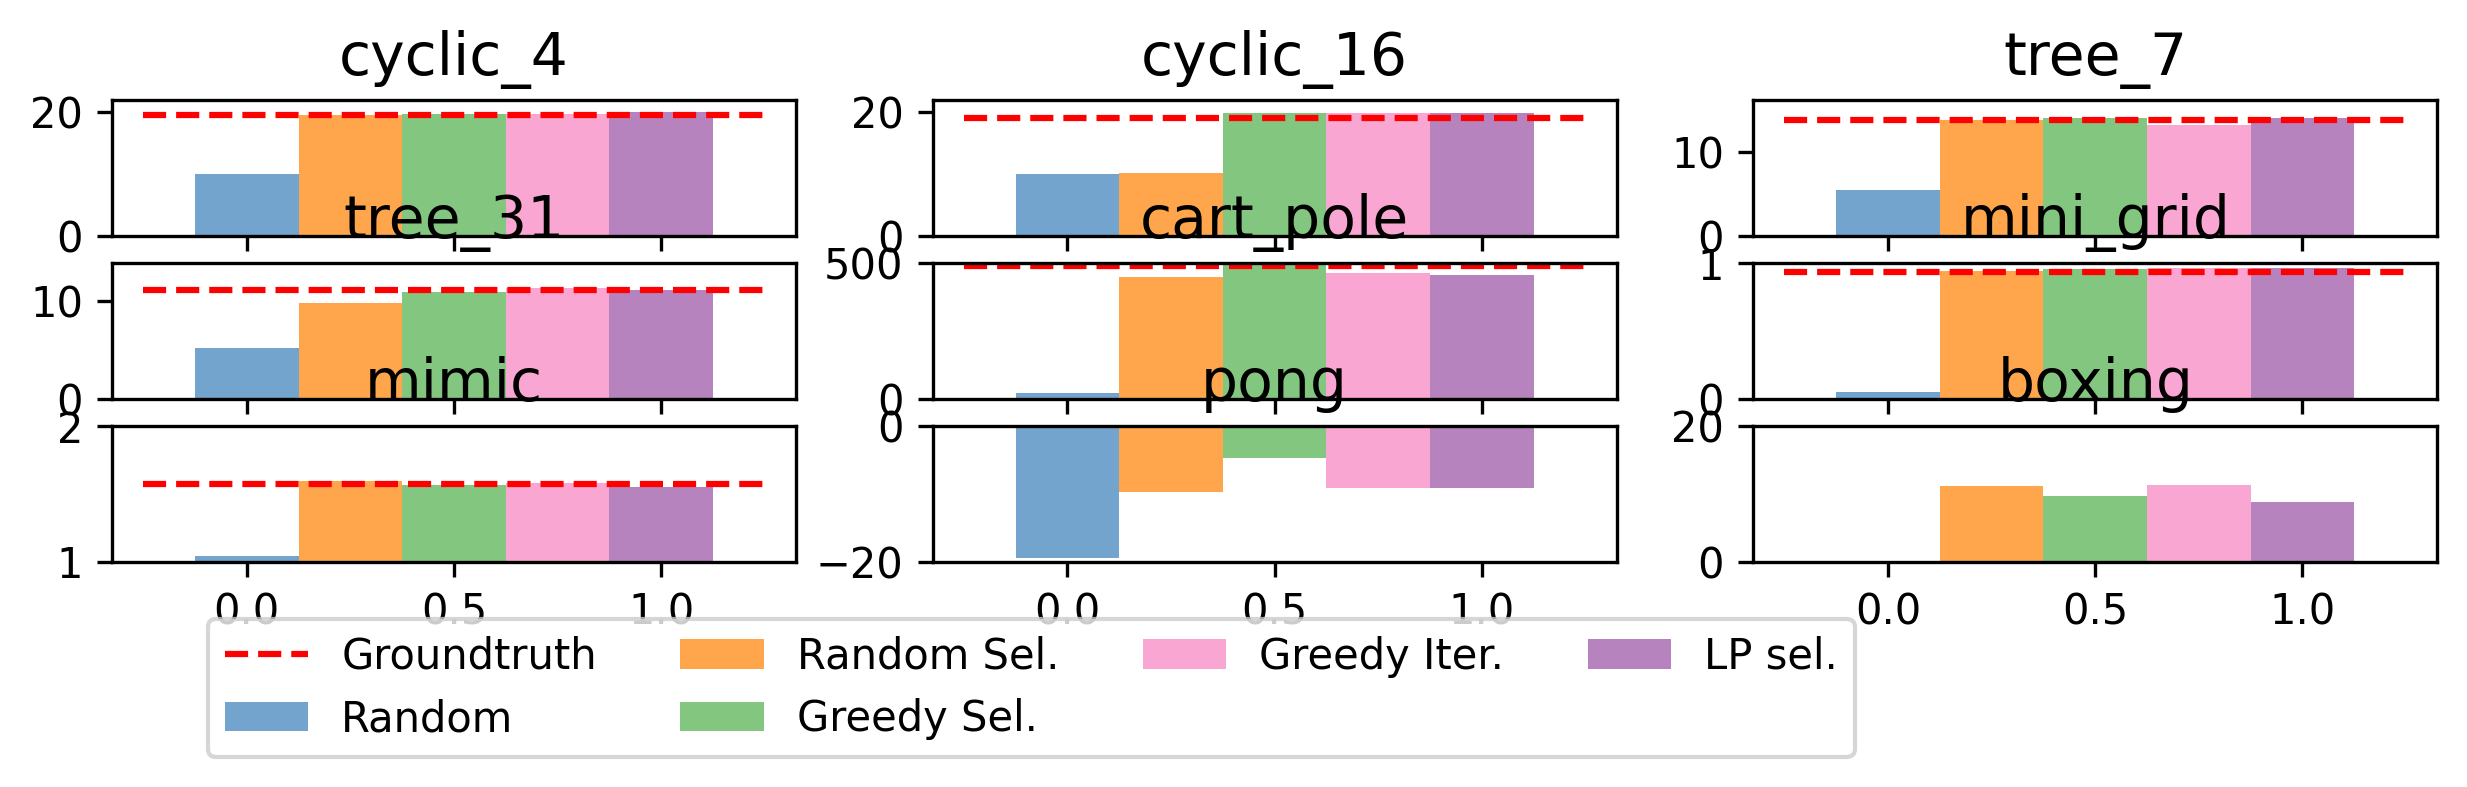

In [11]:
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
                  'y_lim': [[[0,22],[0,22],[0,(10*4/7+20*3/7)+2]],[[0,(10*25/31+20*6/31)+2],[0,500],[0,1]],[[1,2],[-20,0],[0,20]]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

num_by_env = {
    "cyclic_4": 3, 
    "cyclic_16": 2,
    "tree_7": 2, 
    "tree_31": 2, 
    "cart_pole": 15, 
    "mini_grid": 40,
    "mimic": 60,
    "pong": 40,
    "boxing": 30,
}

for i in range(len(environments)):
    x_groups = list(range(5))
    idx = number_concepts.index(num_by_env[environments[i]])
    y_vals = np.array([random_results[i][idx],random_selection[i][idx],
                greedy_selection[i][idx],greedy_iterative_selection[i][idx],
                lp_selection[i][idx]])
    y_vals = np.mean(y_vals,axis=1)
    x,y = index_to_tuple(i)

    d = {
        0: 'Random',
        1: 'Random Sel.',
        2: 'Greedy Sel.',
        3: 'Greedy Iter.',
        4: 'LP sel.'
    }

    plot_bar(ax[x][y],x_groups,y_vals,[0 for i in range(len(y_vals))], d,bar_format)
    if environments[i] == "cart_pole":
        ax[x][y].hlines(490,-0.25,1.25,label="Groundtruth",color="red",linestyle="--")
    else:
        ax[x][y].hlines(np.mean(basic_comparison[i][idx]),-0.25,1.25,label="Groundtruth",color="red",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods.pdf",dpi=300, bbox_inches='tight')

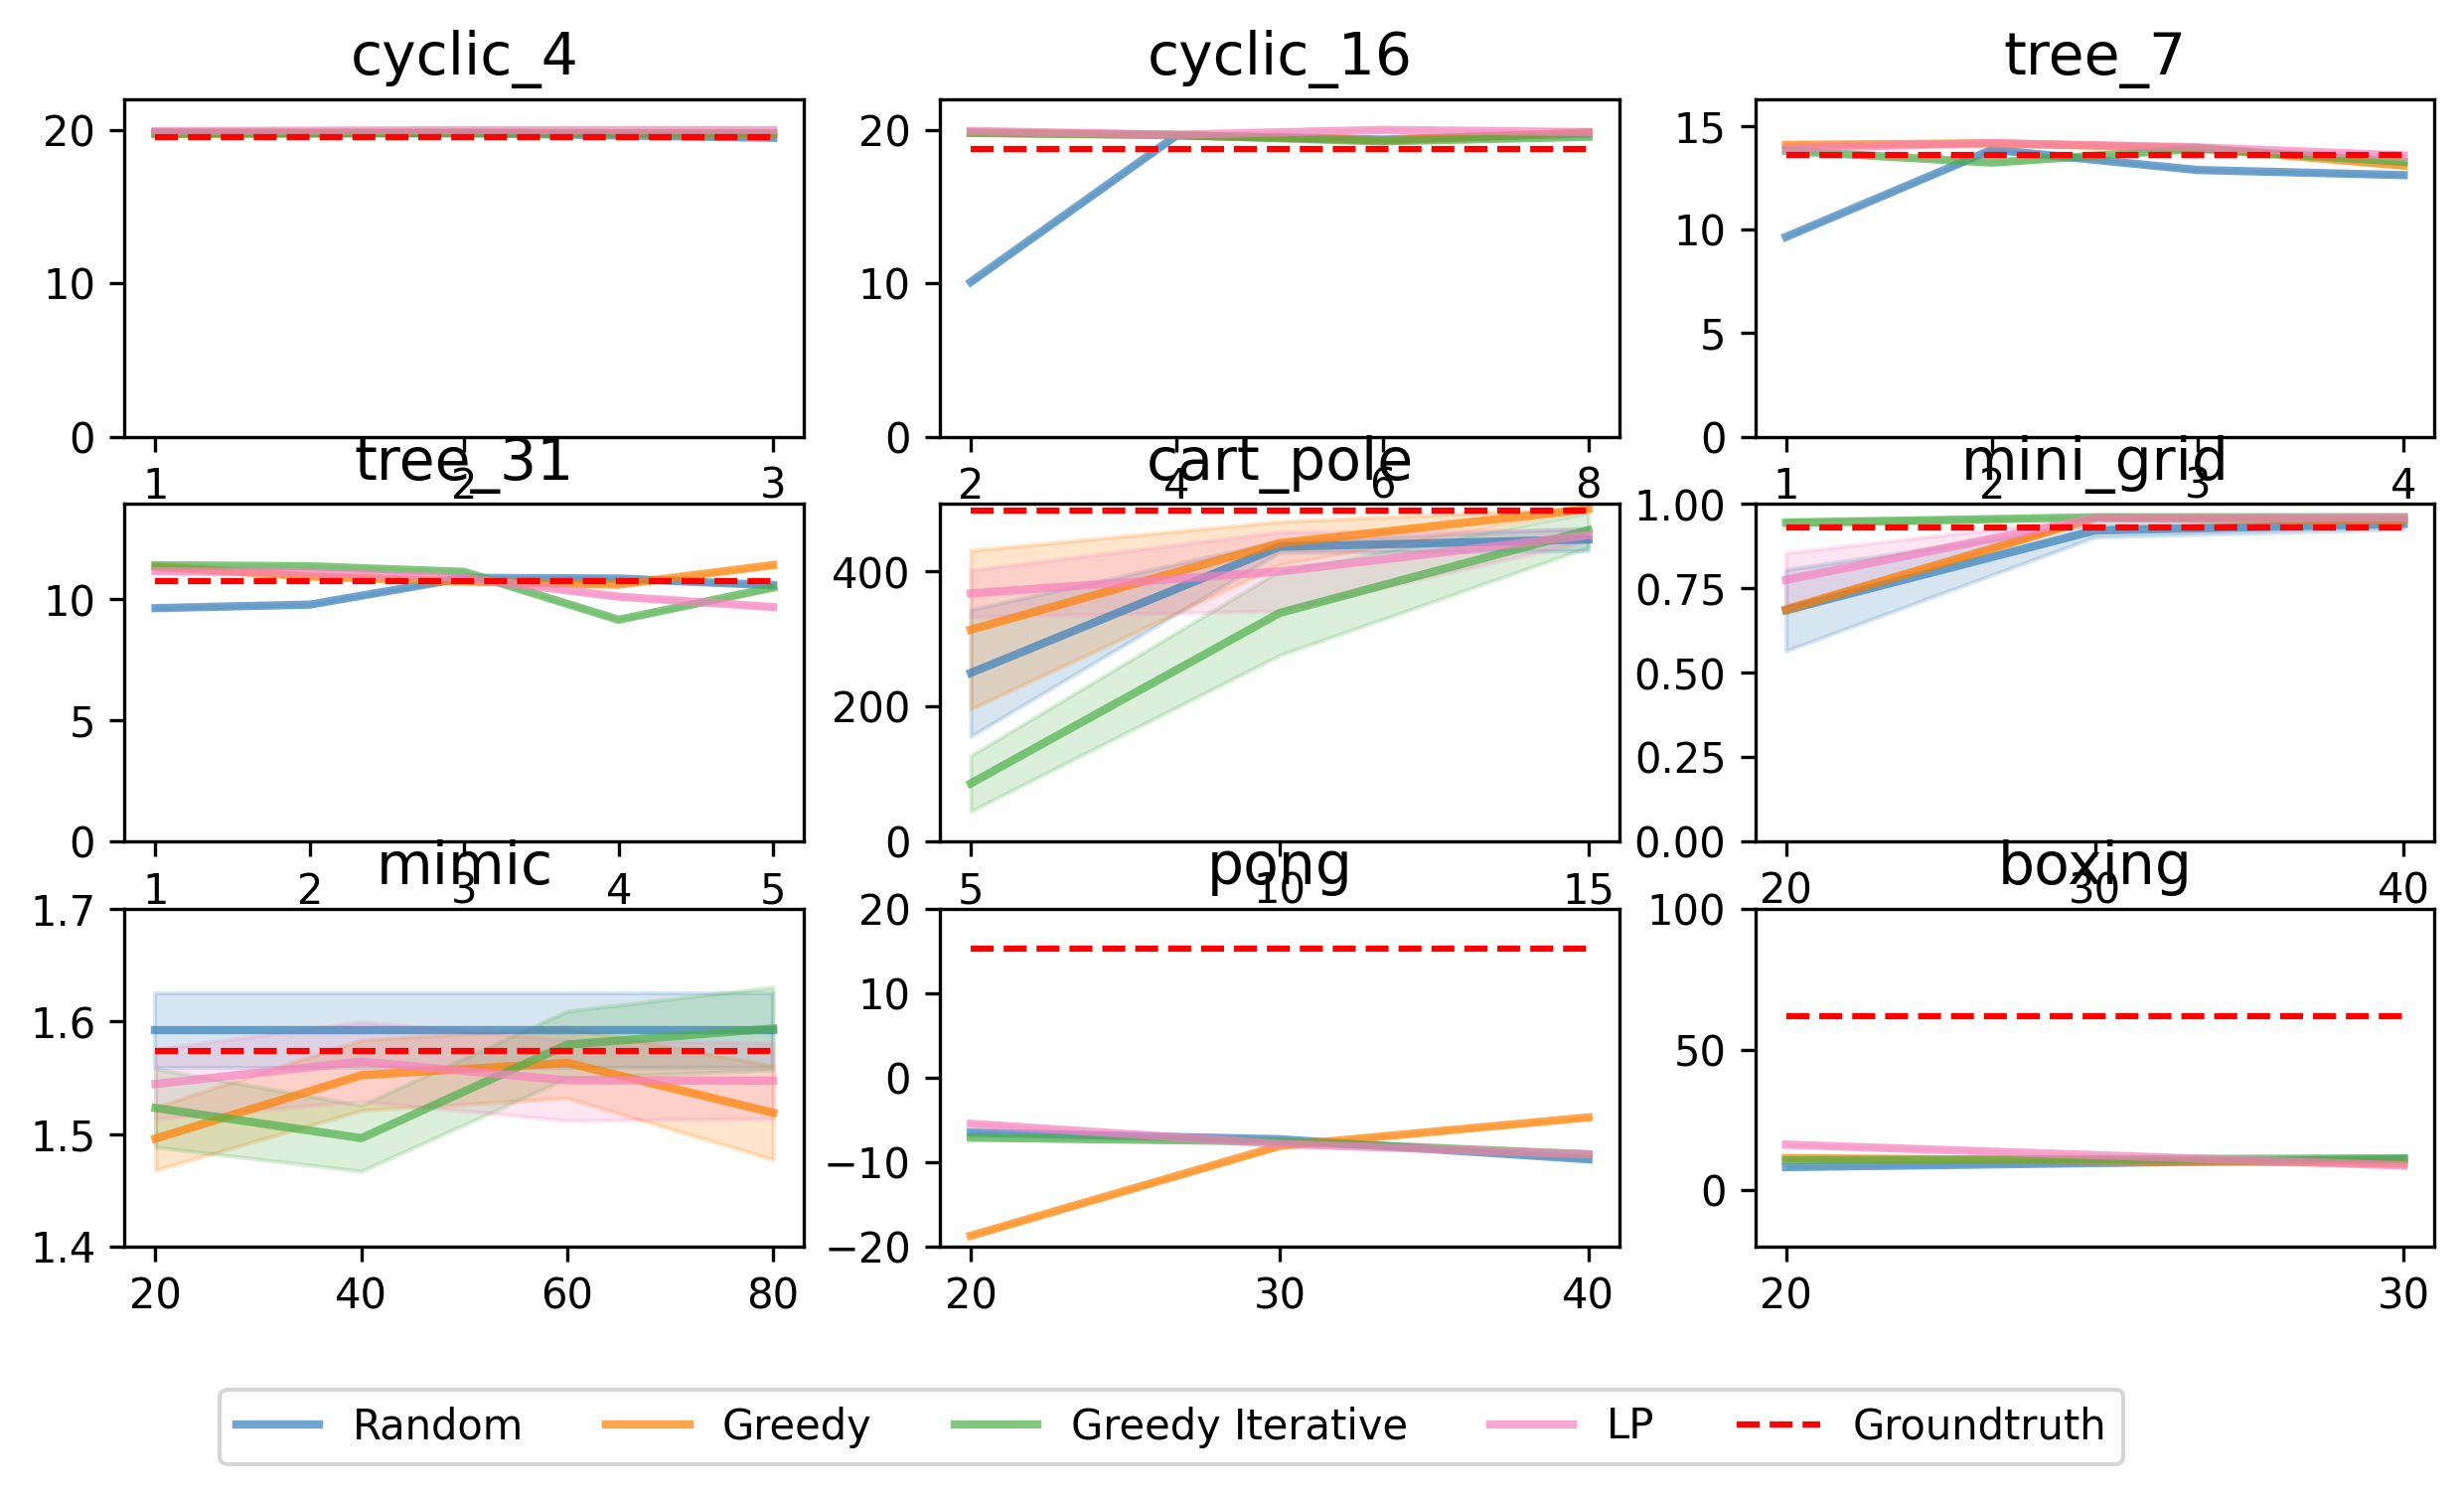

In [19]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

num_by_env = {
    "cyclic_4": [1,2,3], 
    "cyclic_16": [2,4,6,8],
    "tree_7": [1,2,3,4], 
    "tree_31": [1,2,3,4,5], 
    "cart_pole": [5,10,15], 
    "mini_grid": [20,30,40],
    "mimic": [20,40,60,80],
    "pong": [20,30,40],
    "boxing": [20,30],
}

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,5),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,22],[0,22],[0,(10*4/7+20*3/7)+2]],[[0,(10*25/31+20*6/31)+2],[0,500],[0,1]],[[1.4,1.7],[-20,20],[-20,100]]],
    'x_ticks': [[[num_by_env[environments[3*i+j]],num_by_env[environments[3*i+j]]] for j in range(3)] for i in range(3)]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}

all_labels = ["Random","Greedy","Greedy Iterative","LP"]

for i in range(len(environments)):
    x_groups = [num_by_env[environments[i]] for arr in [random_selection,greedy_selection,greedy_iterative_selection,lp_selection]]
    x_vals = num_by_env[environments[i]]
    x_indices = [number_concepts.index(i) for i in x_vals]
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [random_selection,greedy_selection,greedy_iterative_selection,lp_selection]]
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [random_selection,greedy_selection,greedy_iterative_selection,lp_selection]]
    y_vals = np.array(y_vals)[:,x_indices]
    y_std = np.array(y_std)[:,x_indices]

    x,y = index_to_tuple(i)


    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)
    if len(x_indices) > 0:
        if environments[i] == "cart_pole":
            ax[x][y].hlines(490,np.min(x_groups),np.max(x_groups),label="Groundtruth",color="red",linestyle="--")
        else:
            ax[x][y].hlines(np.mean([np.mean(basic_comparison[i][j]) for j in x_indices]),np.min(x_groups),np.max(x_groups),label="Groundtruth",color="red",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 5, 'bbox_to_anchor': (0.15,-0.05),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/number_of_concepts_basic.pdf",dpi=300, bbox_inches='tight')

In [22]:
greedy_selection

(1.4959366379766645, 0.10842376001657217)

In [35]:
np.mean(basic_comparison[6][13]),np.std(basic_comparison[6][13])/15**.5

(1.573602488874189, 0.05757702860921292)

In [32]:
basic_comparison[6][9]

[1.8364820516874587,
 1.3385600071408679,
 1.3547032090788456,
 1.6133253123846722,
 1.409135873535229,
 1.5807897851008432,
 1.7563656353561128,
 1.5292953782222882,
 1.5019504698847377,
 1.2062681105390536,
 1.4775493818238472,
 1.3799766723328786,
 1.7331054334653178,
 1.8335808973917764,
 2.05294911740393]

## Imperfect Concepts

In [124]:
training_times = {
    'cyclic_4':10_000,
    'cyclic_16':10_000,
    'tree_7': 25_000, 
    'tree_31': 25_000,
    'cart_pole': 1_000_000,
    'mini_grid': 250_000,
    'mimic': 250_000,
    'pong': 2_000_000,
    'boxing': 2_000_000,
}

In [125]:
fixed_accuracies = [[0.5,0.75,0.9],[0.5,0.75,0.9]]+[[0.5,0.75,0.9,0.95] for i in range(2)]+[[0.5,0.75,0.9] for i in range(5)]

num_concepts_selected = [2,2,2,2,15,40,40]
num_concepts = [3,15,4,6,24,44,141]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31","cart_pole","mini_grid","mimic"]

greedy_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
imperfect_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
multiple_selection = [[0 for i in range(len(fixed_accuracies[i]))] for i in range(len(environments))]
for j,e in enumerate(environments):
    for i,n in enumerate(fixed_accuracies[j]):
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'num_concepts_selected': num_concepts_selected[j], 
                        'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_intervention': False,
                        'cbm_accuracy_by_concept': [n for i in range(num_concepts[j])]})
        print(e,len(matching_params))
        assert len(matching_params) <= 3
        if len(matching_params) > 0 and 'inaccurate_comparison' in matching_params[0] and 'multiple_lp' in matching_params[0]['inaccurate_comparison']:
            imperfect_comparison = matching_params[0]['inaccurate_comparison']
            res = [
                [i['inaccurate_comparison']['greedy']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['lp']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['imperfect_lp']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['multiple_lp']['reward'] for i in matching_params],
            ]

        else:
            res = [[0],[0],[0],[0]]

        greedy_selection[j][i] = res[0]
        lp_selection[j][i] = res[1]
        imperfect_selection[j][i] = res[2]
        multiple_selection[j][i] = res[3]

        

cyclic_4 3
cyclic_4 3
cyclic_4 3
cyclic_16 3
cyclic_16 3
cyclic_16 3
tree_7 3
tree_7 3
tree_7 3
tree_7 3
tree_31 3
tree_31 3
tree_31 3
tree_31 3
cart_pole 3
cart_pole 3
cart_pole 3
mini_grid 3
mini_grid 3
mini_grid 3
mimic 3
mimic 3
mimic 3


cyclic_4 0 0 [10.169871794871796, 10.743189102564102, 12.045673076923077]
cyclic_4 0 1 [18.349759615384617, 16.55849358974359, 10.009214743589743]
cyclic_4 0 2 [18.518830128205128, 17.665464743589745, 19.35536858974359]
cyclic_4 1 0 [10.22235576923077, 12.164663461538462, 13.328125]
cyclic_4 1 1 [15.461137820512821, 15.802884615384615, 16.295673076923077]
cyclic_4 1 2 [19.591346153846153, 18.529246794871796, 19.53485576923077]
cyclic_4 2 0 [10.857371794871796, 10.037259615384615, 10.141426282051283]
cyclic_4 2 1 [15.046875, 15.506009615384615, 15.48477564102564]
cyclic_4 2 2 [17.768830128205128, 18.717548076923077, 16.57091346153846]
cyclic_4 3 0 [10.618990384615385, 9.917067307692308, 14.04727564102564]
cyclic_4 3 1 [15.18349358974359, 11.573717948717949, 19.108974358974358]
cyclic_4 3 2 [19.62900641025641, 18.896233974358974, 18.151442307692307]
cyclic_16 0 0 [10.351362179487179, 10.611378205128204, 10.09334935897436]
cyclic_16 0 1 [16.088141025641026, 14.883413461538462, 12.38381410

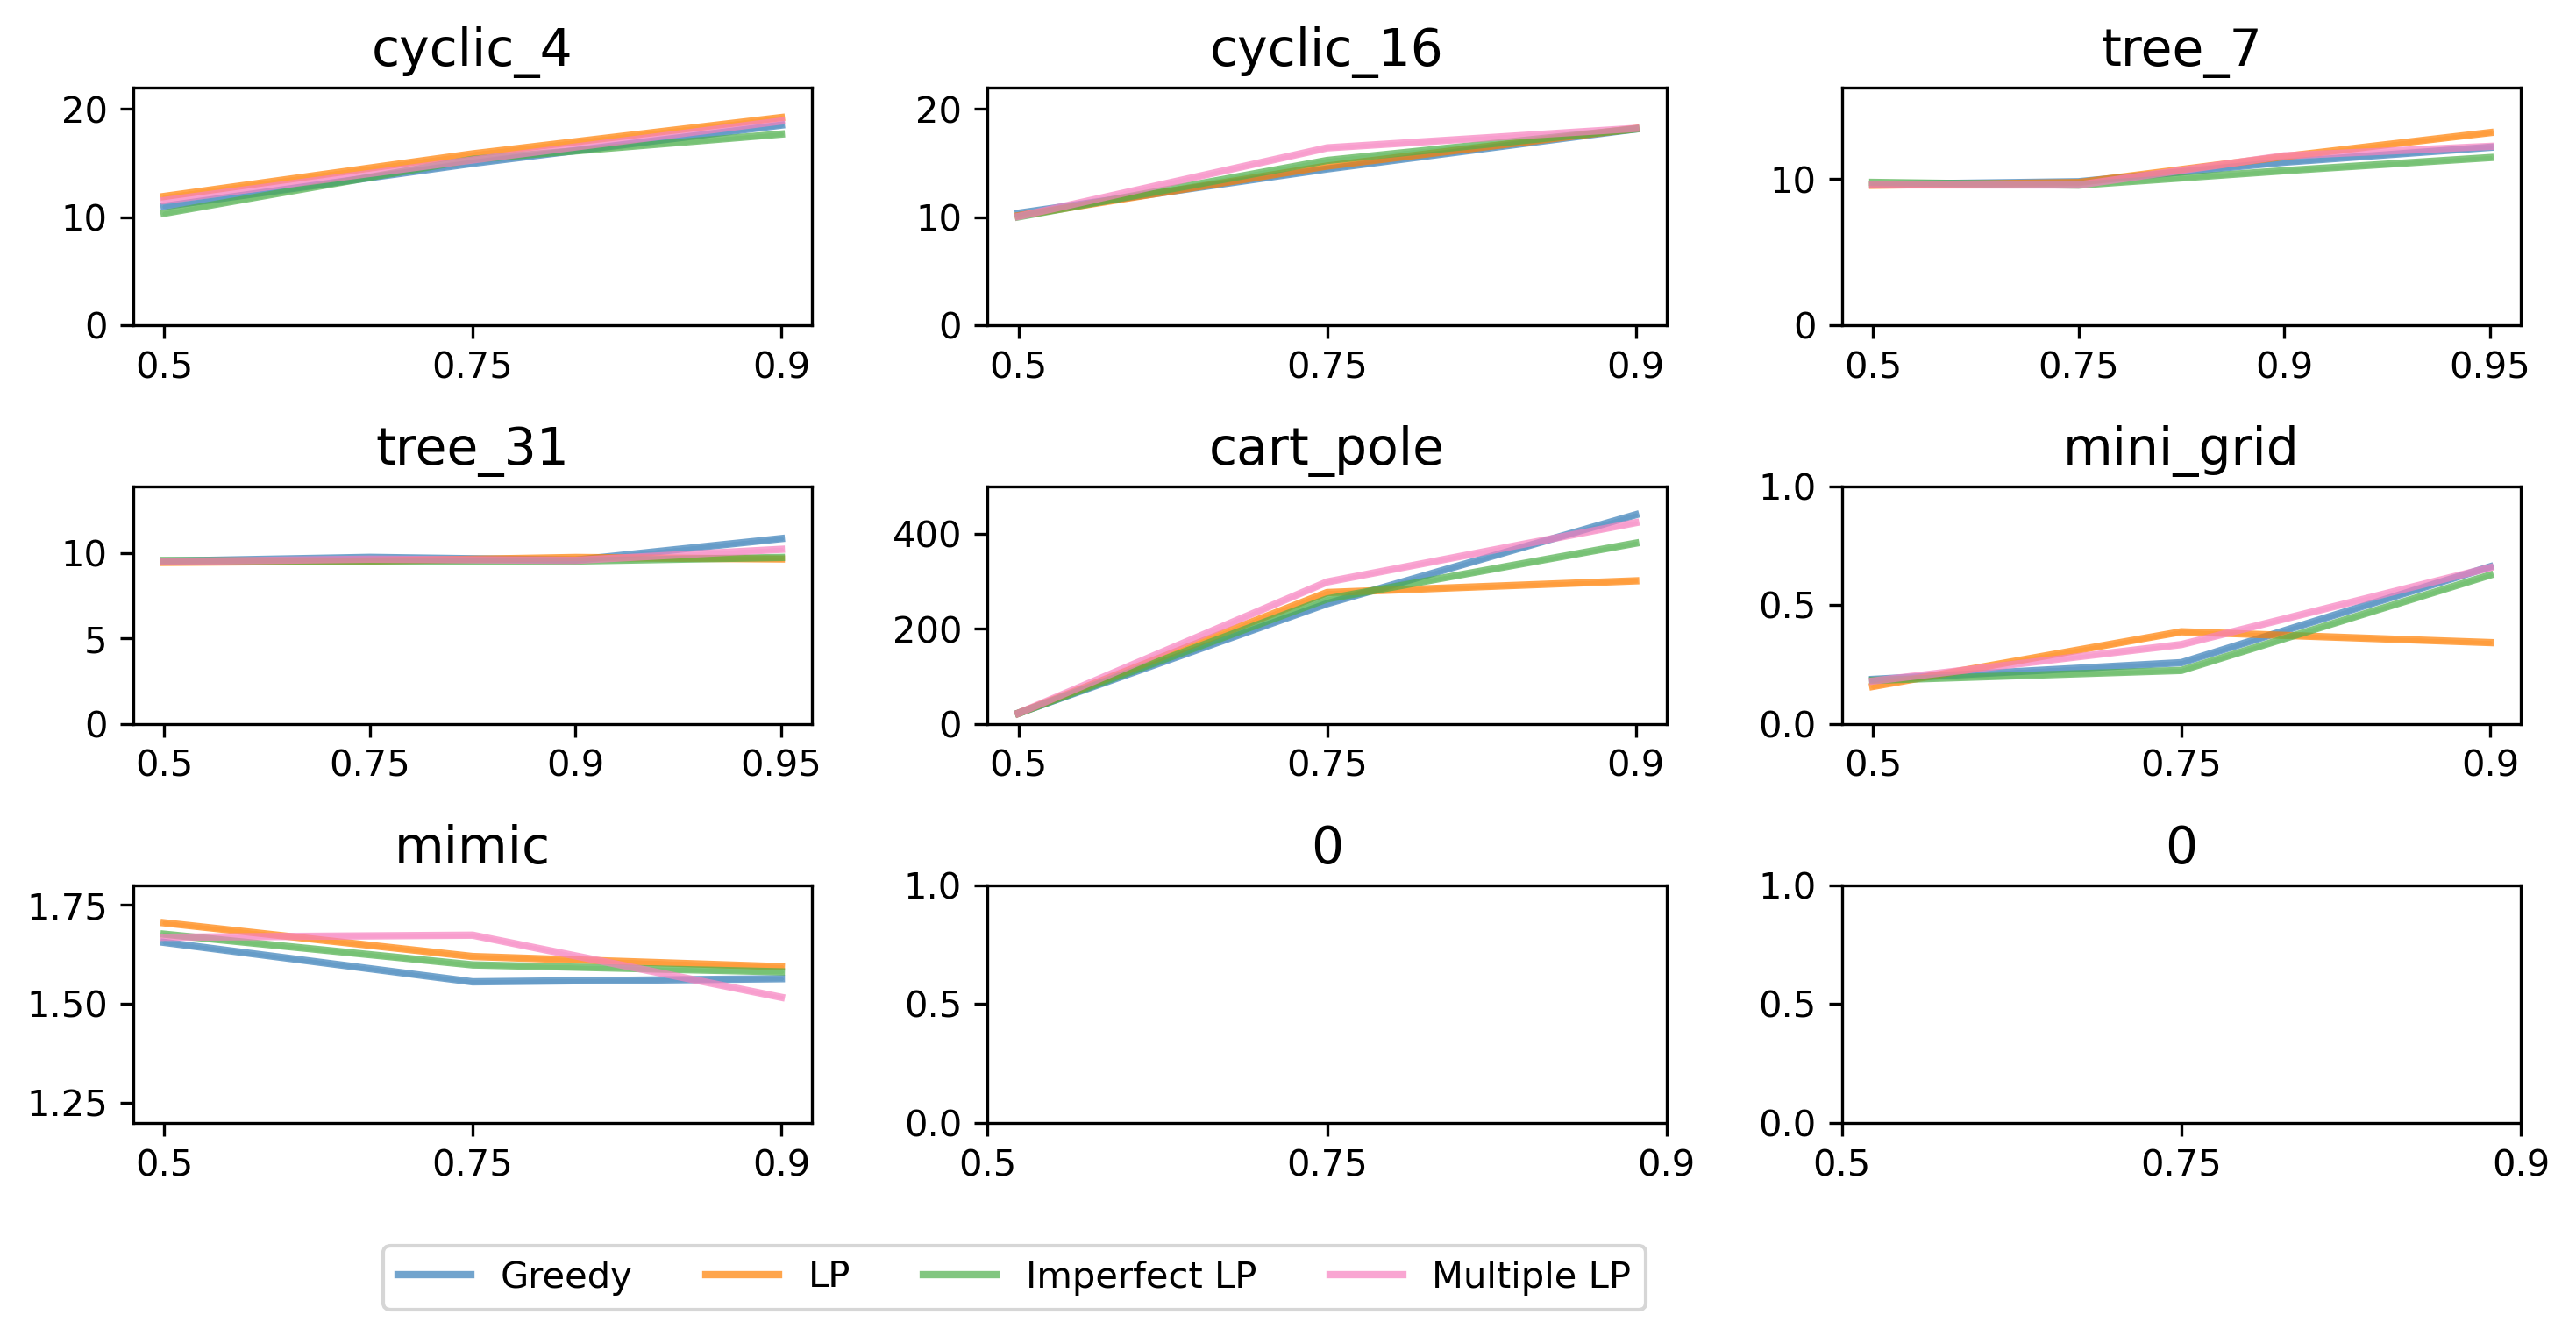

In [126]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,5),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,22],[0,22],[0,(10*4/7+20*3/7)+2]],[[0,(10*25/31+20*6/31)+2],[0,500],[0,1]],[[1.2,1.8],[0,1],[0,1]]],
    'x_ticks': [[[list(range(len(fixed_accuracies[3*i+j]))),fixed_accuracies[3*i+j]] for j in range(3)] for i in range(3)]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Greedy","LP","Imperfect LP","Multiple LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[i]))) for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]

    for idx,arr in enumerate([greedy_selection,lp_selection,imperfect_selection,multiple_selection]):
        for j in range(len(arr[i])):
            print(environments[i],idx,j,arr[i][j])

    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5*0 for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection
                                                                                            ]]
    x,y = index_to_tuple(i)
    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.05),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_comparison.pdf",dpi=300, bbox_inches='tight')

In [ ]:
fixed_accuracy=[0.75,0.75,0.95,0.95]
num_concepts_selected = [[1,2,3],[1,2,3,4],[1,2,3,4],[1,2,3,4]]
num_concepts = [3,15,4,6]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31"]

greedy_selection = [[0 for i in range(len(num_concepts_selected[i]))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(num_concepts_selected[i]))] for i in range(len(environments))]
imperfect_selection = [[0 for i in range(len(num_concepts_selected[i]))] for i in range(len(environments))]
multiple_selection = [[0 for i in range(len(num_concepts_selected[i]))] for i in range(len(environments))]

for j,e in enumerate(environments):
    for i,n in enumerate(num_concepts_selected[j]):
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'num_concepts_selected': n, 
                        'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_intervention': False,
                        'cbm_accuracy_by_concept': [fixed_accuracy[j] for i in range(num_concepts[j])]})
        assert len(matching_params) <= 3
        if len(matching_params) > 0 and 'inaccurate_comparison' in matching_params[0] and 'multiple_lp' in matching_params[0]['inaccurate_comparison']:
            res = [
                [i['inaccurate_comparison']['greedy']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['lp']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['imperfect_lp']['binary']['reward'] for i in matching_params],
                [i['inaccurate_comparison']['multiple_lp']['reward'] for i in matching_params],
            ]

        else:
            res = [[0],[0],[0],[0]]

        greedy_selection[j][i] = res[0]
        lp_selection[j][i] = res[1]
        imperfect_selection[j][i] = res[2]
        multiple_selection[j][i] = res[3]

        

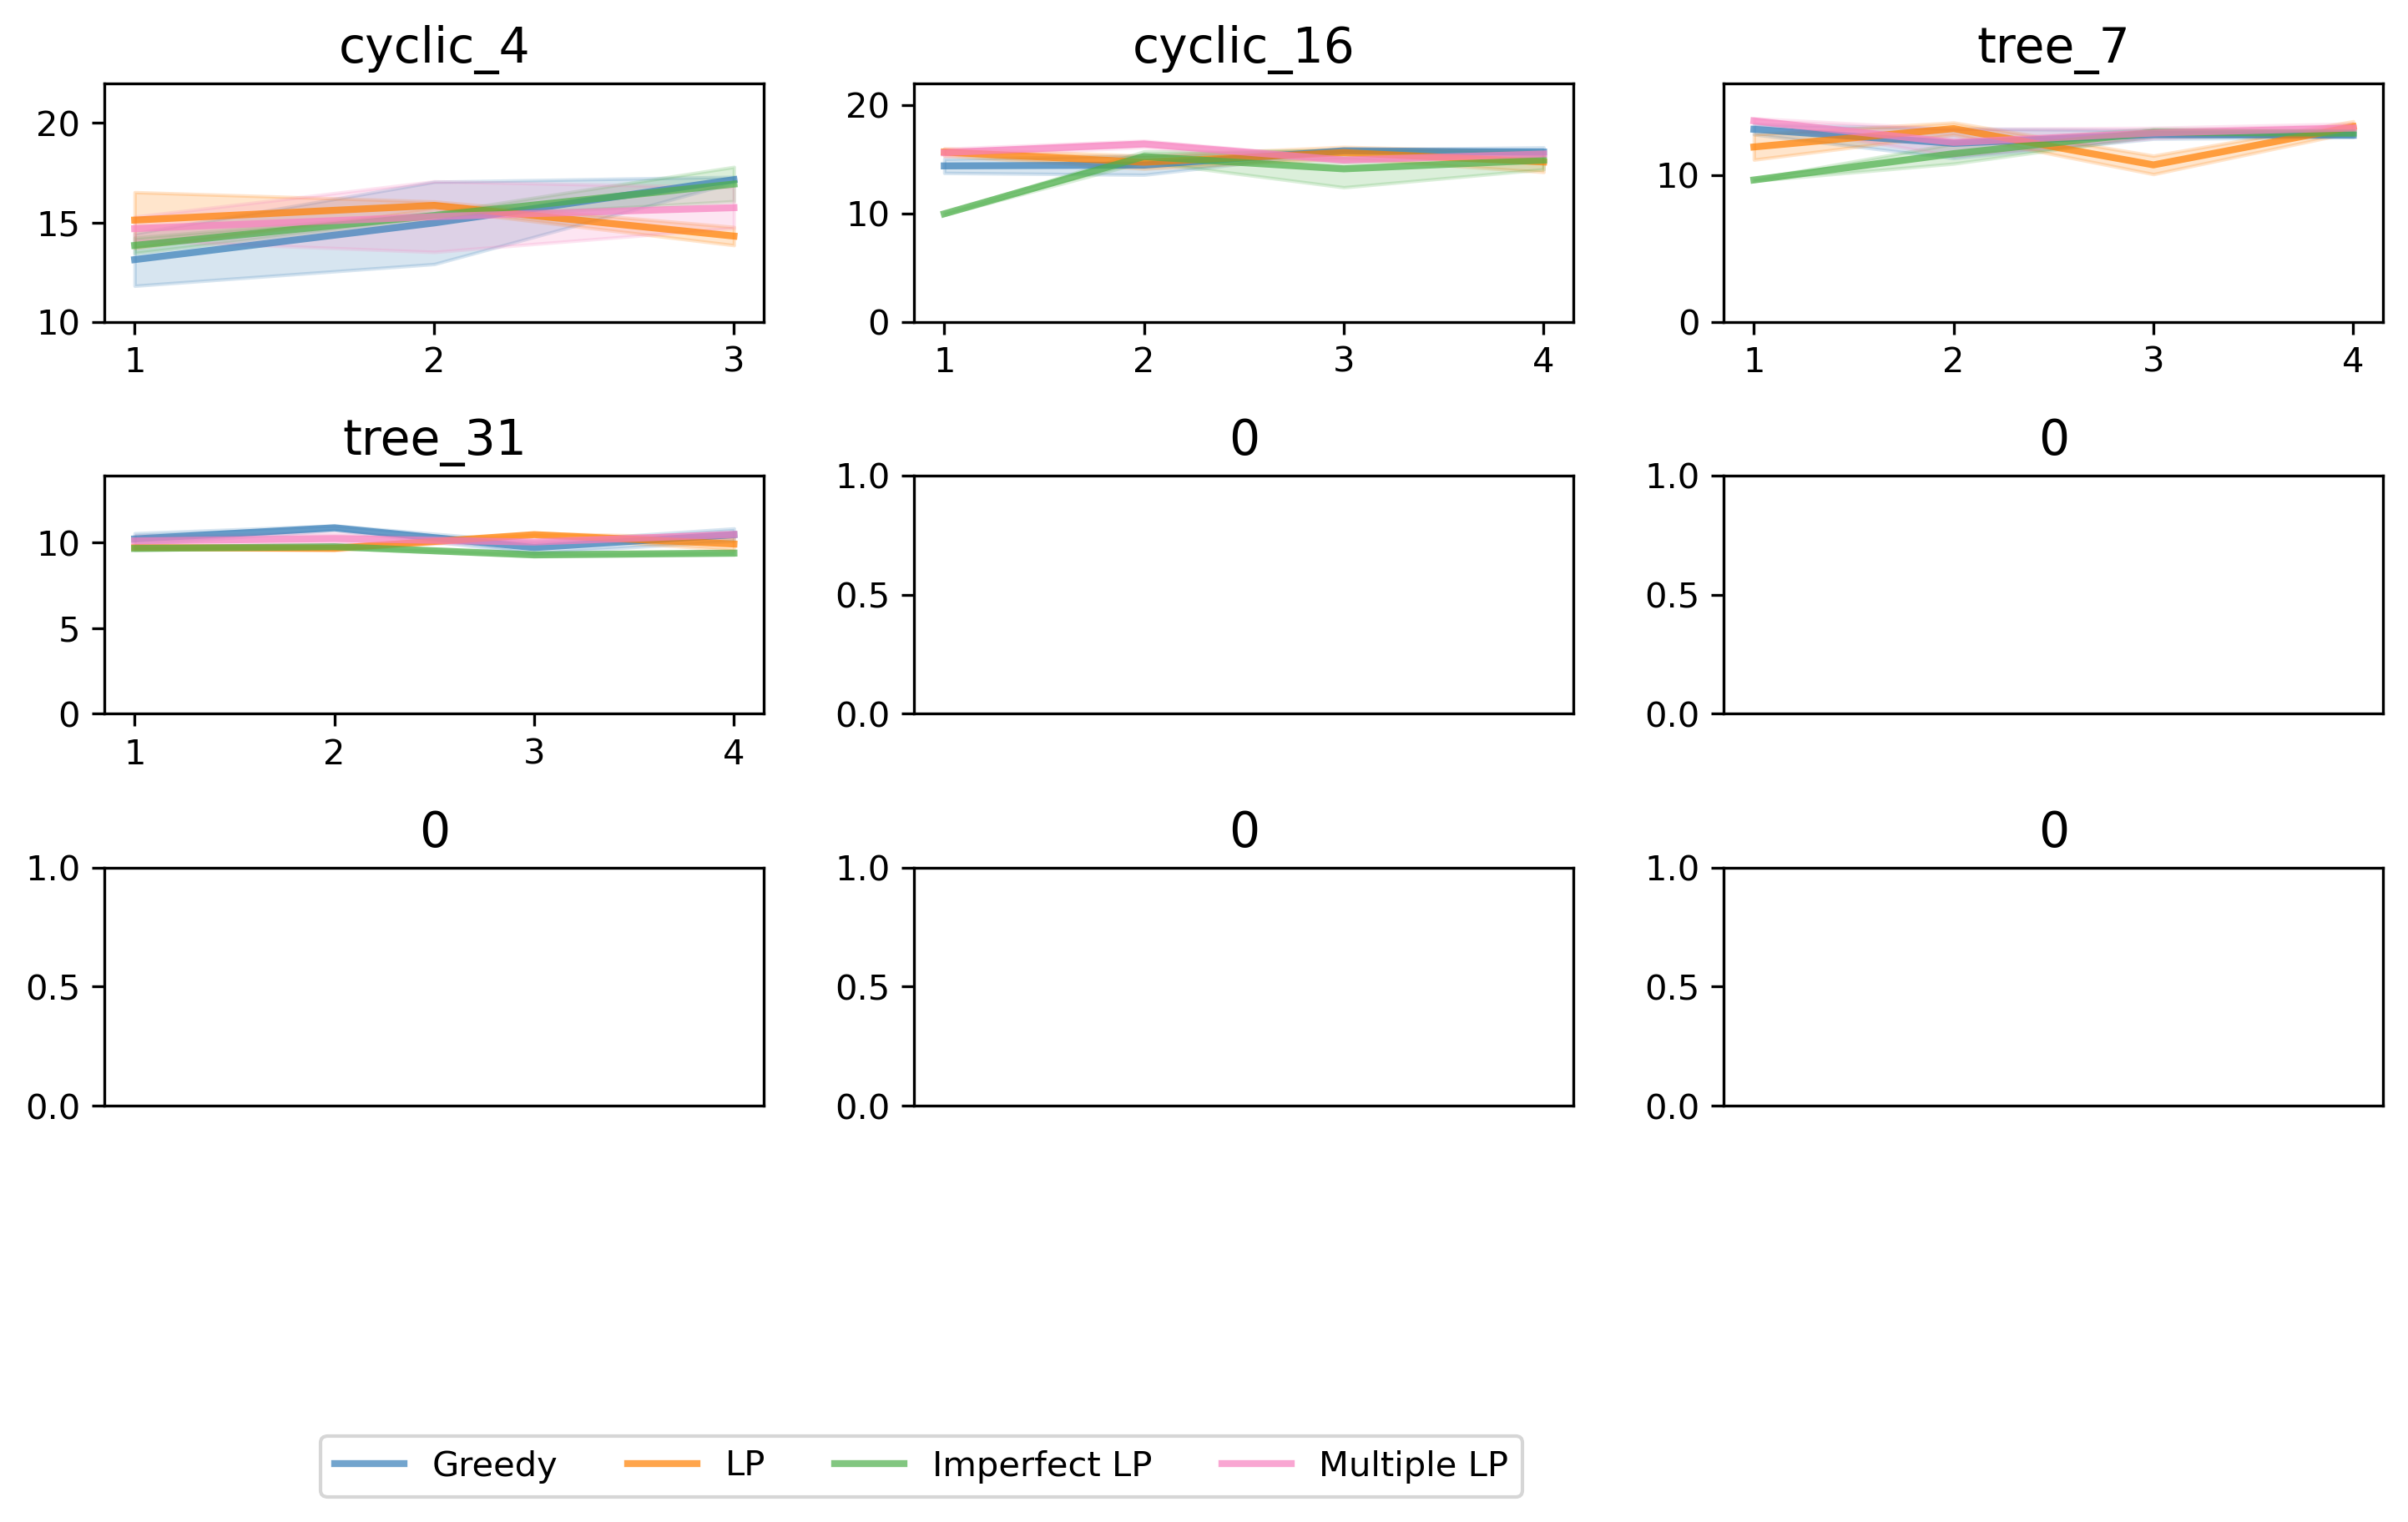

In [ ]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)
x_ticks = flatten_to_square(num_concepts_selected)

sup_y_label = ""
overall_format = {'figsize':(10,5),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[10,22],[0,22],[0,(10*4/7+20*3/7)+2]],[[0,(10*25/31+20*6/31)+2],[0,1],[0,1]],[[0,1],[0,1],[0,1]]],
    'x_ticks': [[[list(range(len(j))),j] if j!=0 else [[],[]] for j in i] for i in x_ticks]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Greedy","LP","Imperfect LP","Multiple LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[i]))) for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x_vals = num_concepts_selected[i]
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x,y = index_to_tuple(i)
    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_comparison.pdf",dpi=300, bbox_inches='tight')

### Intervention

In [127]:
intervention_probability = [0.25,0.5,0.75]
num_concepts_selected = [2,2,2,2,15,40,40]
fixed_accuracies = [[0.5,0.75,0.75],[0.5,0.75,0.75,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5],[0.75,0.75,0.75,0.5],[0.75,0.75,0.75,0.75,0.75,0.5]]
fixed_accuracies += [[0.75 for i in range(24)],[0.9 for i in range(44)],[0.75 for i in range(141)]]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31","cart_pole","mini_grid","mimic"]

greedy_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
imperfect_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
multiple_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]

for i,n in enumerate(intervention_probability):
    for j,e in enumerate(environments):
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'num_concepts_selected': num_concepts_selected[j], 
                        'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_intervention': True,
                        'intervention_probability': n,'cbm_accuracy_by_concept': fixed_accuracies[j]})
        if len(matching_params) > 0:
            print(e,len(matching_params))
            res = [
                [i['intervention_comparison']['greedy']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['lp']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['imperfect_lp']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['multiple_lp']['reward'] for i in matching_params],
            ]

        else:
            res = [[0],[0],[0],[0]]

        greedy_selection[j][i] = res[0]
        lp_selection[j][i] = res[1]
        imperfect_selection[j][i] = res[2]
        multiple_selection[j][i] = res[3]

cyclic_4 3
cyclic_16 3
tree_7 3
tree_31 3
cart_pole 2
mini_grid 1
mimic 1
cyclic_4 4
cyclic_16 4
tree_7 3
tree_31 3
cart_pole 1
mini_grid 1
mimic 1
cyclic_4 3
cyclic_16 3
tree_7 3
tree_31 3
cart_pole 1
mini_grid 1
mimic 1


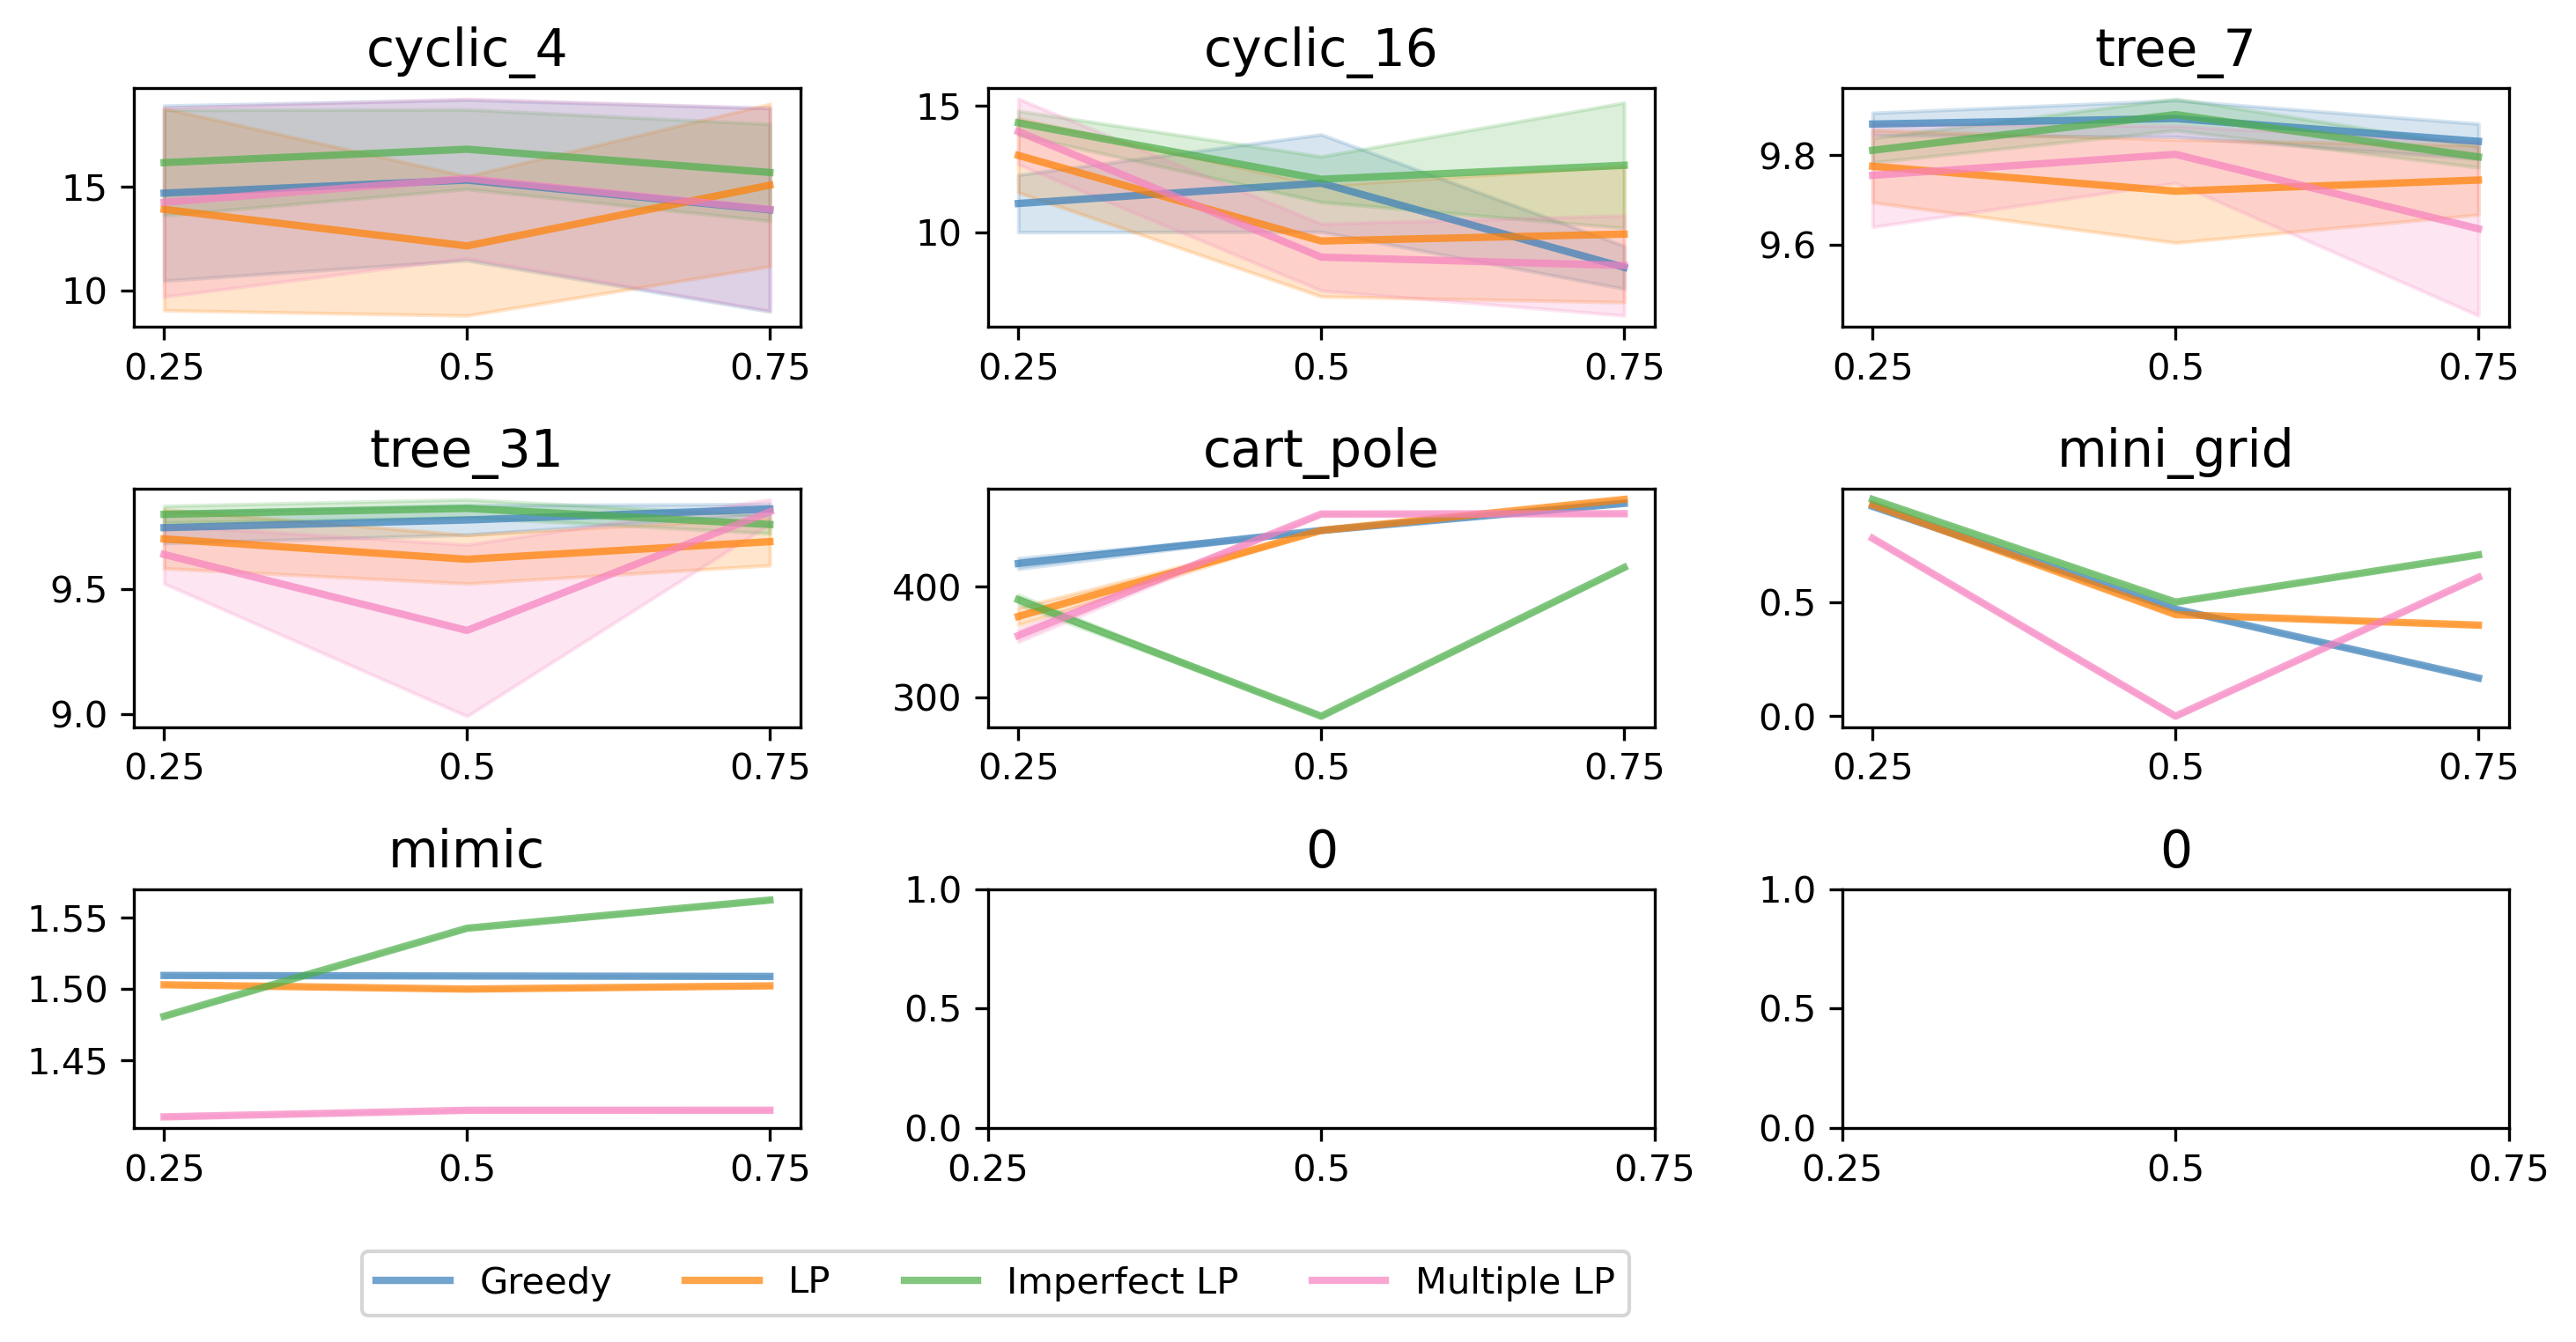

In [129]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,5),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(intervention_probability))),intervention_probability] for i in range(3)] for j in range(3)]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Greedy","LP","Imperfect LP","Multiple LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[i]))) for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x_vals = num_concepts_selected[i]
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x,y = index_to_tuple(i)
    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.05),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/intervention_comparison.pdf",dpi=300, bbox_inches='tight')

In [ ]:
intervention_probability = [0.25,0.5,0.75]
num_concepts_selected = [2,2,2,2]
fixed_accuracies = [[0.5,0.95,0.95],[0.5,0.95,0.95,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5],[0.95,0.95,0.95,0.5],[0.95,0.95,0.95,0.95,0.95,0.5]]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31"]

greedy_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
imperfect_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]
multiple_selection = [[0 for i in range(len(intervention_probability))] for i in range(len(environments))]

for i,n in enumerate(intervention_probability):
    for j,e in enumerate(environments):
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'num_concepts_selected': num_concepts_selected[j], 
                        'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_intervention': True,
                        'intervention_probability': n,'cbm_accuracy_by_concept': fixed_accuracies[j]})
        if len(matching_params) > 0:
            res = [
                [i['intervention_comparison']['greedy']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['lp']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['imperfect_lp']['binary']['reward'] for i in matching_params],
                [i['intervention_comparison']['multiple_lp']['reward'] for i in matching_params],
            ]

        else:
            res = [[0],[0],[0],[0]]

        greedy_selection[j][i] = res[0]
        lp_selection[j][i] = res[1]
        imperfect_selection[j][i] = res[2]
        multiple_selection[j][i] = res[3]


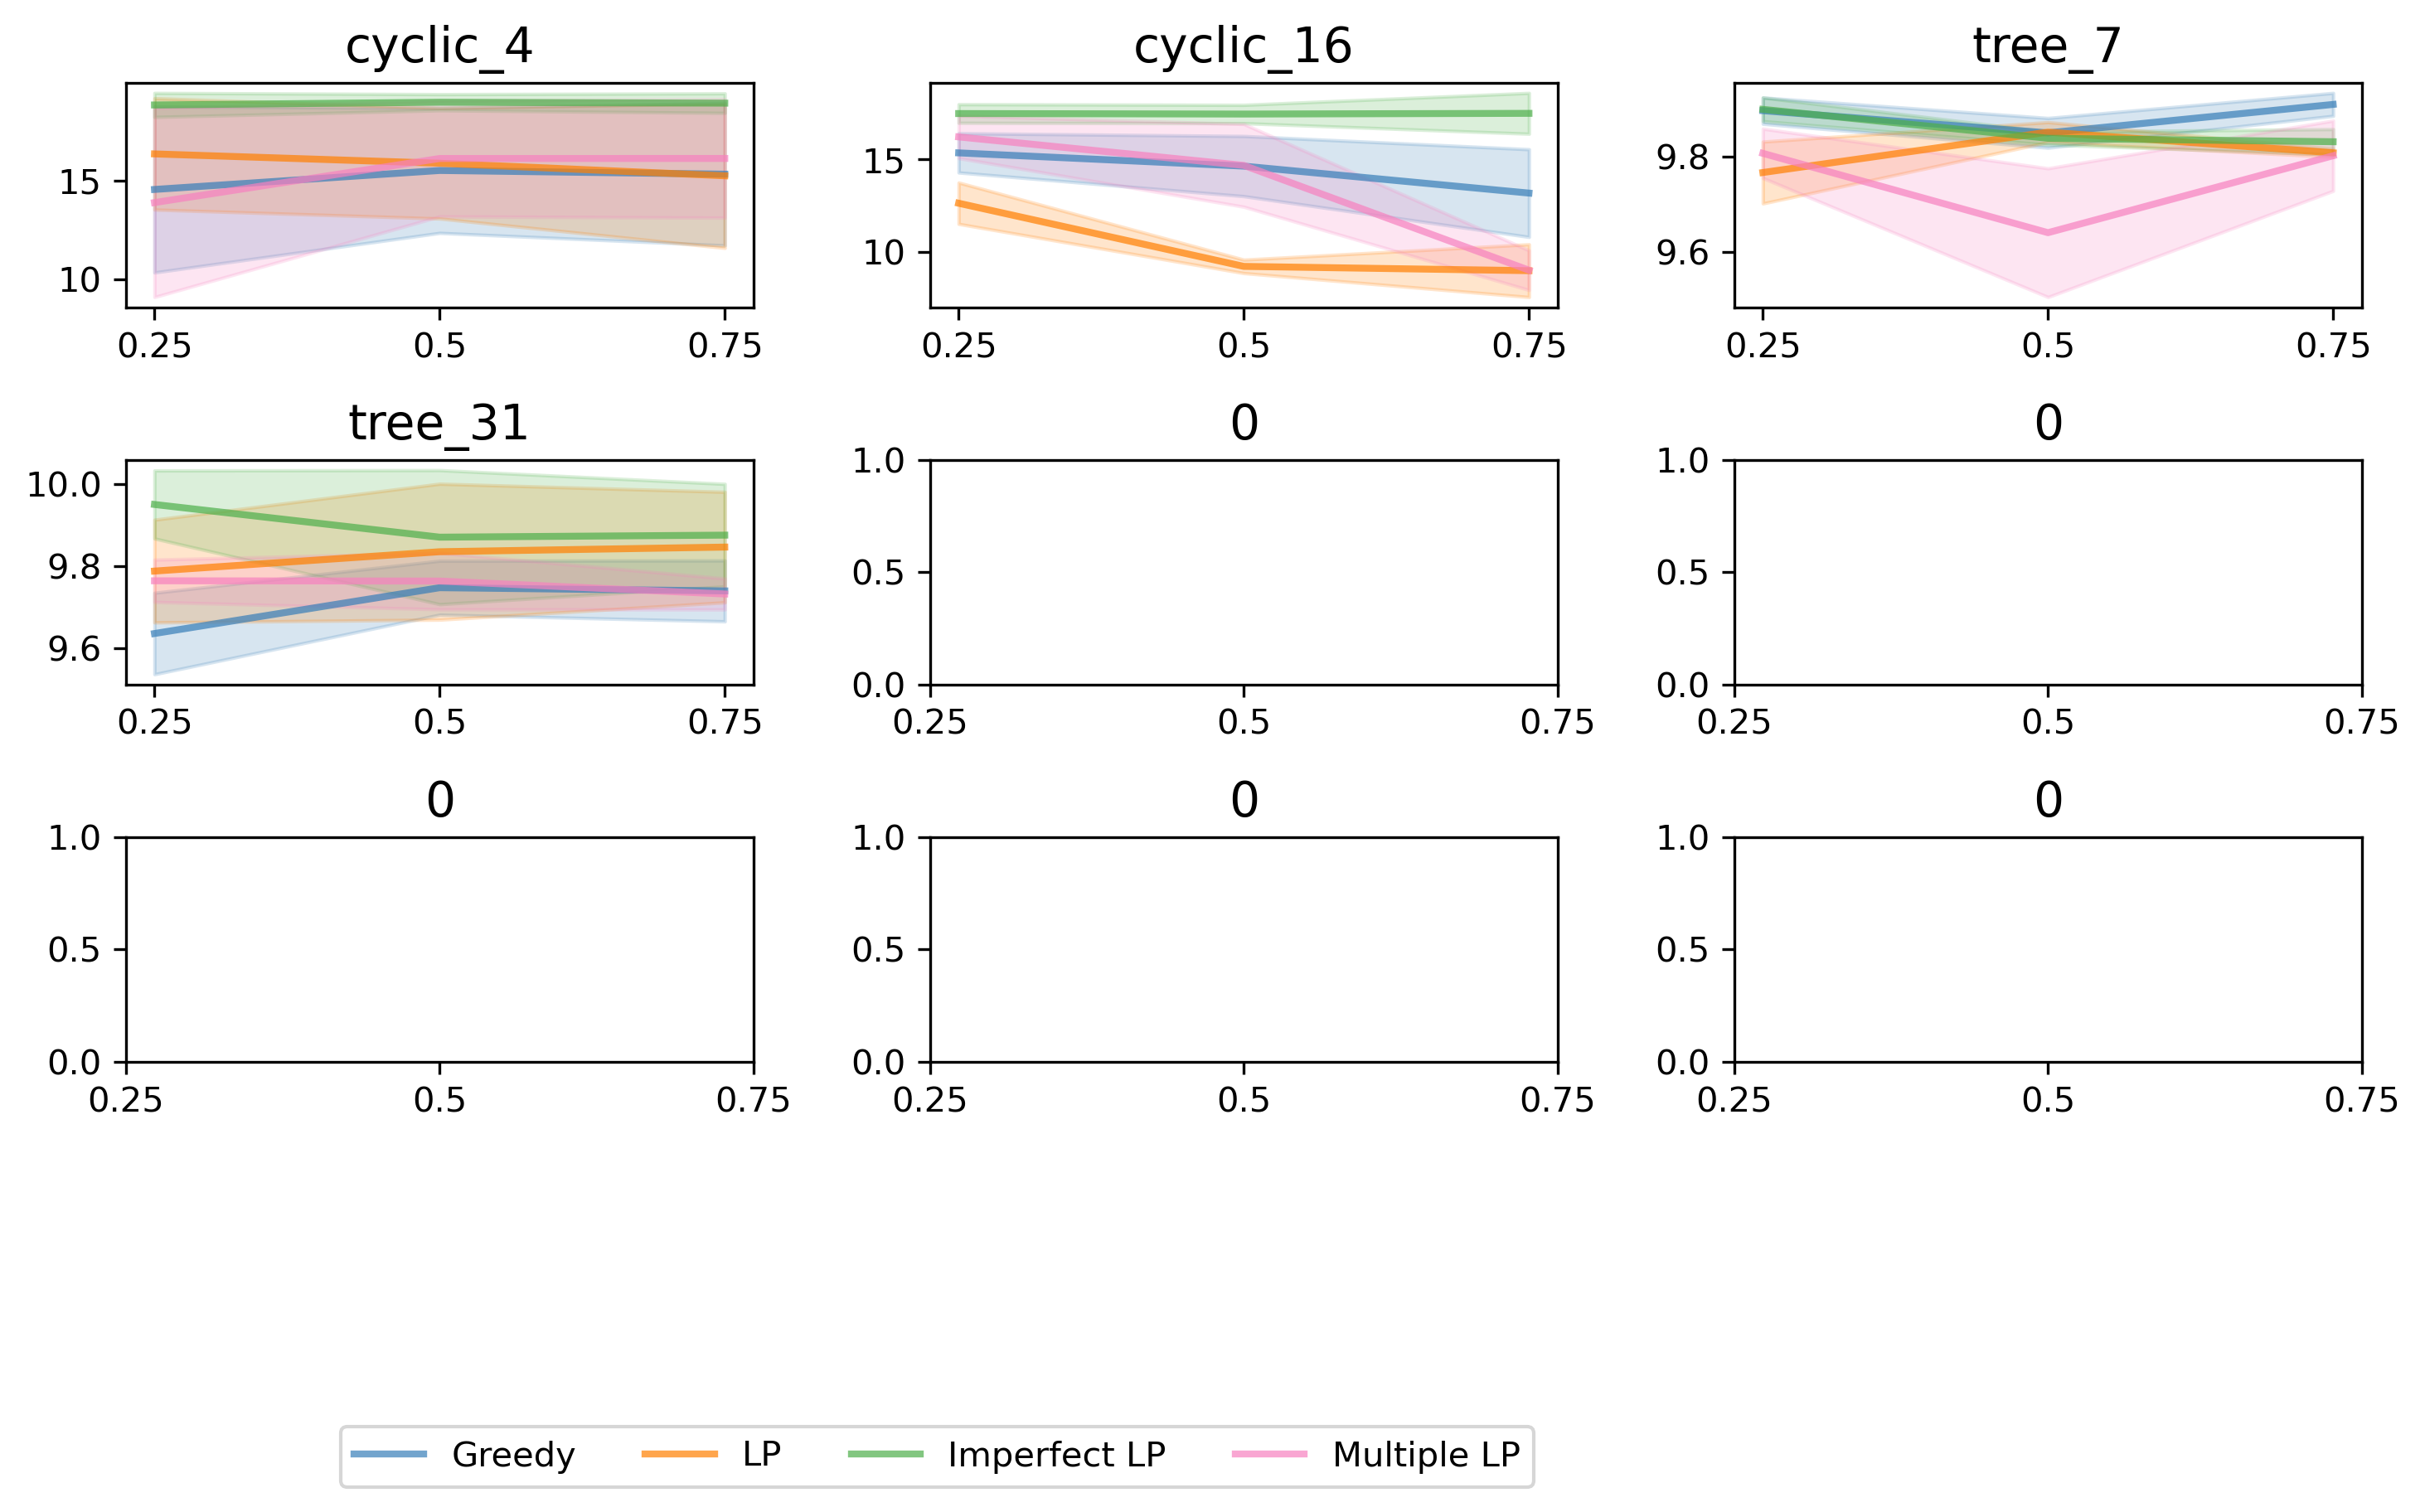

In [ ]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,5),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(intervention_probability))),intervention_probability] for i in range(3)] for j in range(3)]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Greedy","LP","Imperfect LP","Multiple LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[i]))) for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x_vals = num_concepts_selected[i]
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [greedy_selection,lp_selection,imperfect_selection,multiple_selection]]
    x,y = index_to_tuple(i)
    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/intervention_comparison.pdf",dpi=300, bbox_inches='tight')

## Iterative Experiments

In [8]:
training_times = {
    'cyclic_4':10_000,
    'cyclic_16':10_000,
    'tree_7': 25_000, 
    'tree_31': 25_000,
    'cart_pole': 1_000_000,
    'mini_grid': 250_000,
    'mimic': 250_000,
    'pong': 2_000_000,
    'boxing': 2_000_000,
}

In [11]:
# Investigating Selected Pong Concepts
environments = ["cyclic_4","cyclic_16","tree_7","tree_31","cart_pole","mini_grid","mimic"]
num_iterations = [2,2,2,2,3,4,4]
selections = [1,1,1,1,5,10,10]
accuracies = [[],[],[],[],[0.75 for i in range(24)],[0.9 for i in range(44)],[]]
perf_by_iteration = [[[0] for i in range(num_iterations[j])] for j in range(len(environments))]
bayesian_by_iteration = [[[0] for i in range(num_iterations[j])] for j in range(len(environments))]
for i,e in enumerate(environments):
    matching_params = get_results_matching_parameters("iterative","",{'environment_string': e,'num_iterations': num_iterations[i],'selections_per_round': selections[i]})
    if e in ["cart_pole","mini_grid"]:
        matching_params = get_results_matching_parameters("iterative","",{'environment_string': e,'num_iterations': num_iterations[i],'selections_per_round': selections[i],
                                                                    'cbm_accuracy_by_concept': accuracies[i],'training_timesteps': training_times[e]})
        print(e,len(matching_params))

    if len(matching_params) > 0:
        perf_by_iteration[i] = [[m['iterative']['iterative_selection']['reward'][i] for m in matching_params] for i in range(num_iterations[i])]
        bayesian_by_iteration[i] = [[m['iterative']['bayesian']['reward'][i] for m in matching_params] for i in range(num_iterations[i])]

cart_pole 1
mini_grid 3


/tmp/ipykernel_1628037/3549115791.py:27: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


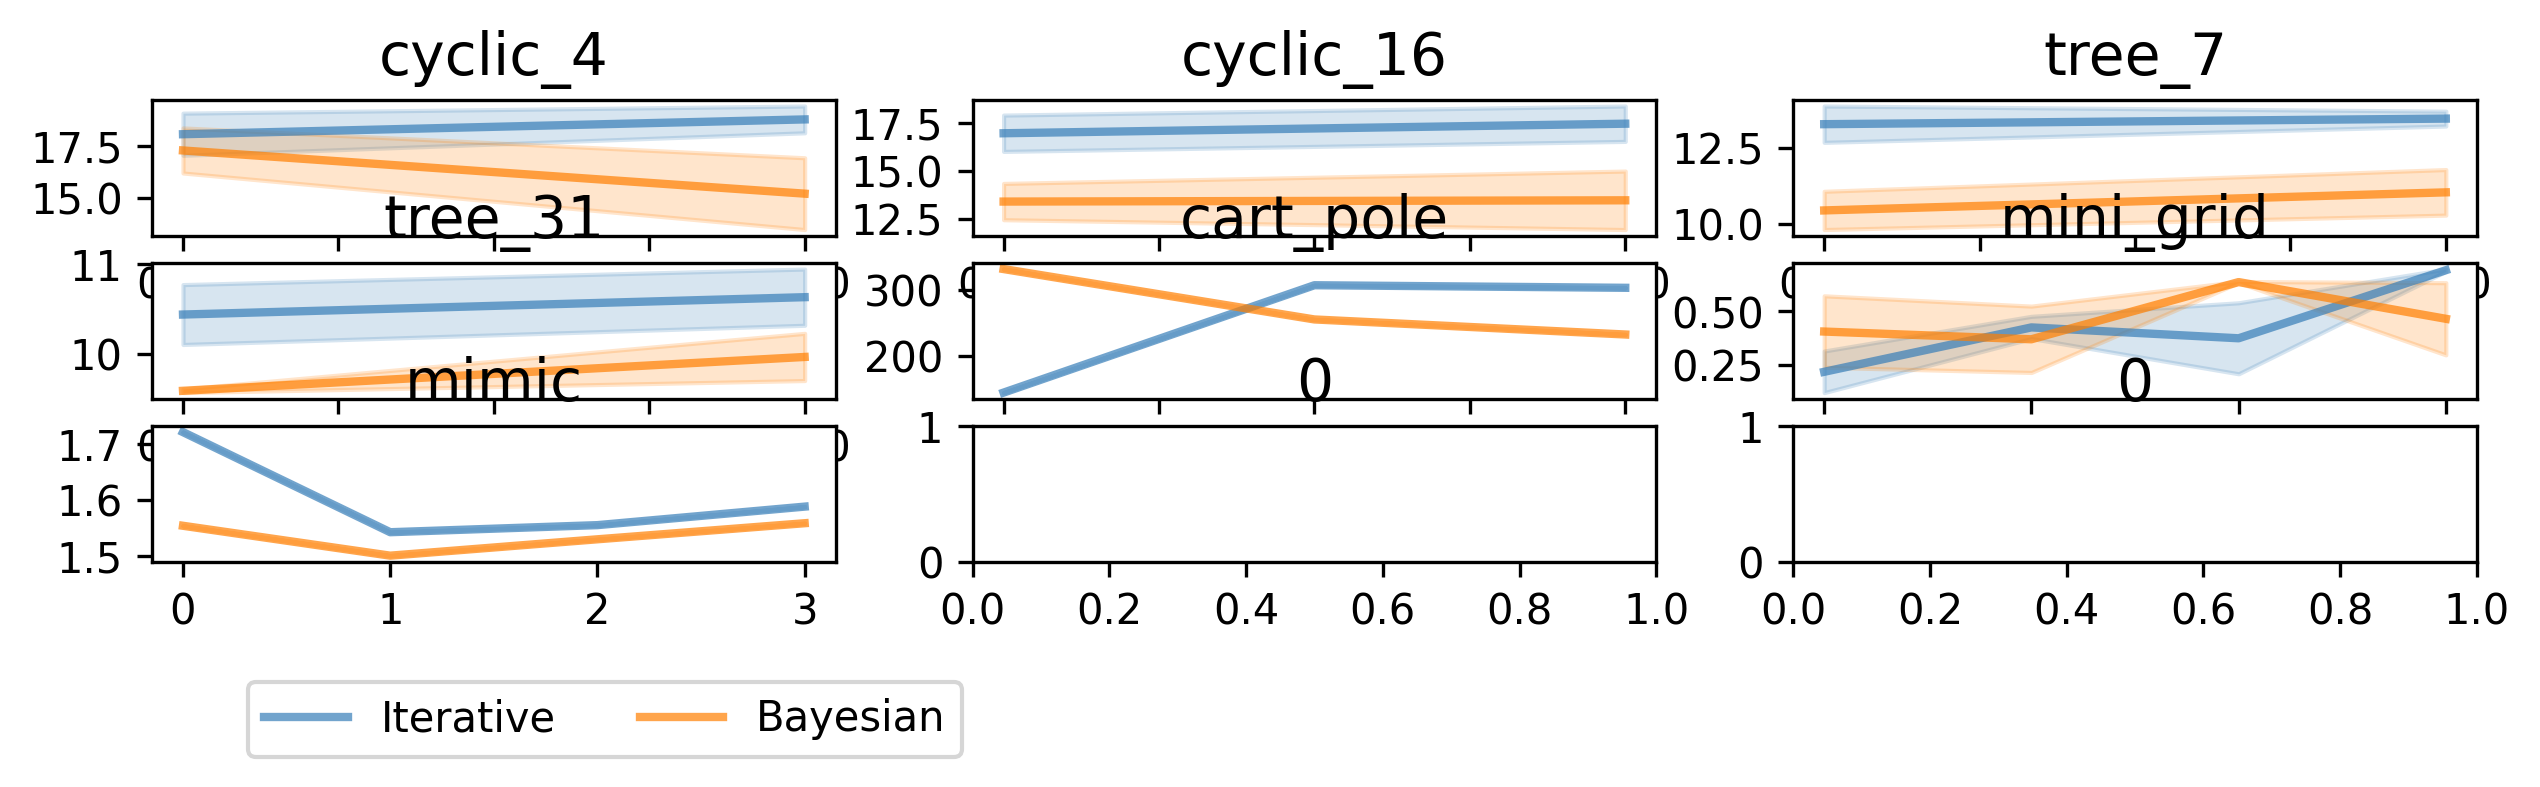

In [12]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Iterative","Bayesian"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[i]))) for arr in [perf_by_iteration,bayesian_by_iteration]]
    x_vals = list(range(1,num_iterations[i]+1))
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [perf_by_iteration,bayesian_by_iteration]]
    x,y = index_to_tuple(i)
    
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [perf_by_iteration,bayesian_by_iteration]]

    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/iterative.pdf",dpi=300, bbox_inches='tight')

In [9]:
# Investigating Selected Pong Concepts
environments = ["cyclic_4","cyclic_16","tree_7","tree_31"]
num_concepts = [3,15,4,6]
num_iterations = 2

perf_by_iteration = [[0 for i in range(num_iterations)] for j in environments]
bayesian_by_iteration = [[0 for i in range(num_iterations)] for j in environments]
for i,e in enumerate(environments):
    matching_params = get_results_matching_parameters("iterative","",{'environment_string': e,'num_iterations': num_iterations,'selections_per_round': 1, 'cbm_accuracy_by_concept': [0.75 for i in range(num_concepts[i])]})
    if len(matching_params) > 0:
        perf_by_iteration[i] = [[m['iterative']['iterative_selection']['reward'][i] for m in matching_params] for i in range(num_iterations)]
        bayesian_by_iteration[i] = [[m['iterative']['bayesian']['reward'][i] for m in matching_params] for i in range(num_iterations)]

/tmp/ipykernel_3779143/1153119264.py:27: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


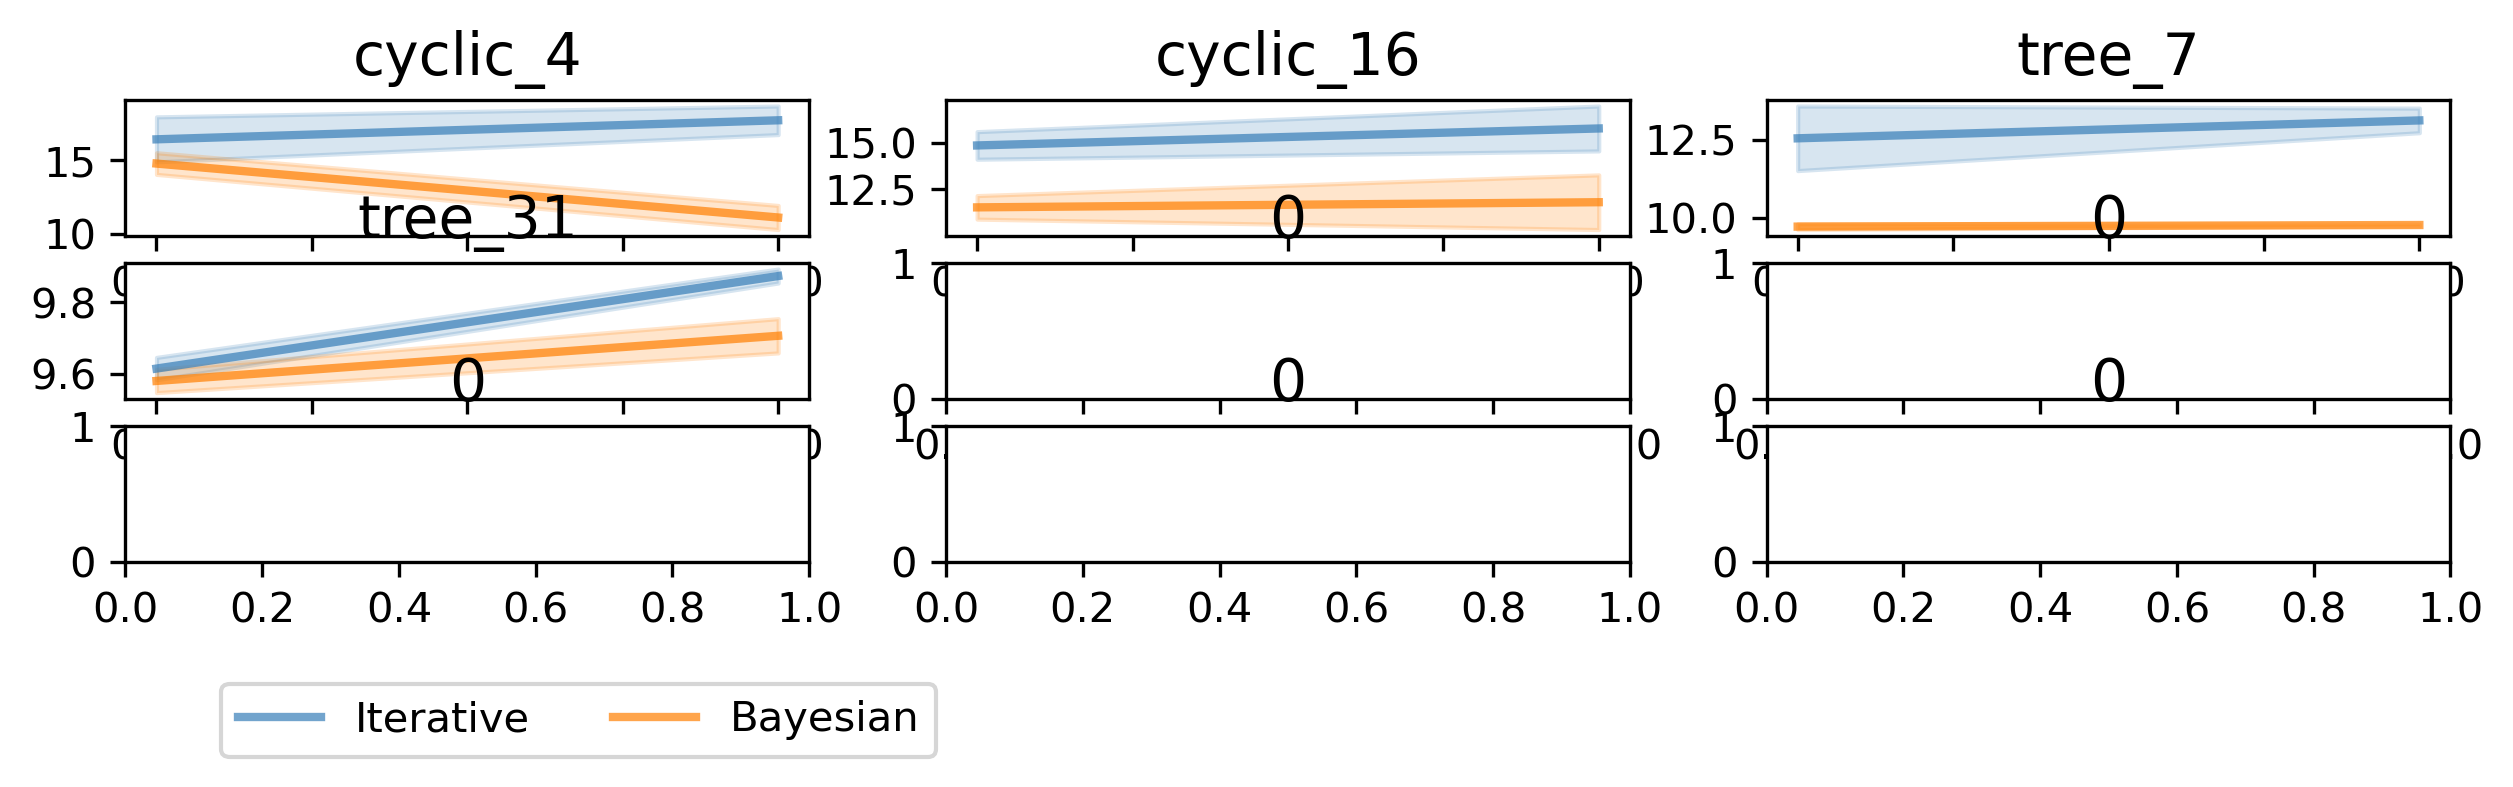

In [9]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Iterative","Bayesian"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[0]))) for arr in [perf_by_iteration,bayesian_by_iteration]]
    x_vals = list(range(1,num_iterations+1))
    y_vals = [[np.mean(arr[i][j]) for j in range(len(arr[i]))] for arr in [perf_by_iteration,bayesian_by_iteration]]
    x,y = index_to_tuple(i)
    y_std = [[np.std(arr[i][j])/len(arr[i][j])**.5 for j in range(len(arr[i]))] for arr in [perf_by_iteration,bayesian_by_iteration]]

    plot_line(ax[x][y],x_groups,y_vals,y_std,all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/iterative.pdf",dpi=300, bbox_inches='tight')

## CUB Experiments

In [48]:
matching_params = get_results_matching_parameters("cub","",{'num_concepts_selected': 311, 'epochs': 50})
perfect_lp = [[m['perfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
chosen_concepts = np.mean([m['perfect']['manual']['reward'] for m in matching_params])
similarity = [[len(set(matching_params[0]['perfect']['lp'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
perfect_lp = np.mean(perfect_lp,axis=0)
similarity = np.mean(similarity,axis=1)

/tmp/ipykernel_3635104/1475245191.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


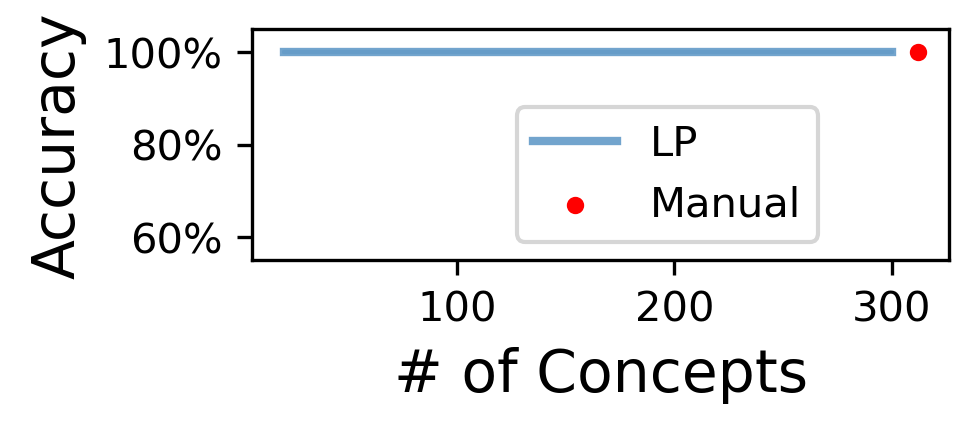

In [49]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,1),
    'style_size': style_size,
    'has_grid': False, 
    'y_ticks': [[[[0.6,0.8,1],["60%","80%","100%"]]]],
    'y_lim': [[[0.55,1.05]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts"]],y_labels=[["Accuracy"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Manual"]

x_groups = [list(range(20,311,20))]
y_vals = [[perfect_lp[min(i,len(perfect_lp)-1)] for i in range(len(x_groups[0]))]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
plt.scatter([312],[chosen_concepts],s=10,c='red',label="Manual")

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.35,-0.01),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/perfect_cub.pdf",dpi=300, bbox_inches='tight')

/tmp/ipykernel_3635104/3550101319.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


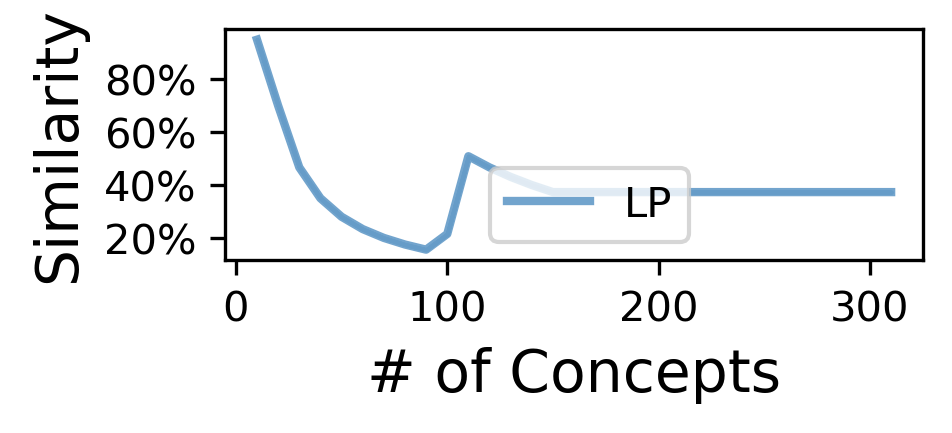

In [50]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,1),
    'style_size': style_size,
    'has_grid': False, 
    'y_ticks': [[[[0,0.2,0.4,0.6,0.8,1],["0%","20%","40%","60%","80%","100%"]]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts"]],y_labels=[["Similarity"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Manual"]

x_groups = [list(range(10,312,10))]
y_vals = [[similarity[min(i,len(perfect_lp)-1)] for i in range(len(x_groups[0]))]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.35,-0.01),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/similarity_cub.pdf",dpi=300, bbox_inches='tight')

In [51]:
imperfect_lp = [[m['imperfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
imperfect_lp = np.mean(imperfect_lp,axis=0)
multiple_lp = [[m['imperfect']['multiple'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
multiple_lp = np.mean(multiple_lp,axis=0)
iterative_lp = [[m['imperfect']['iterative'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
iterative_lp = np.mean(iterative_lp,axis=0)

greedy = [[m['imperfect']['greedy'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
greedy = np.mean(greedy,axis=0)

random_selection = [[m['imperfect']['random'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
random_selection = np.mean(random_selection,axis=0)


chosen_concepts = np.mean([m['imperfect']['manual']['reward'] for m in matching_params])


/tmp/ipykernel_3635104/2675301870.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


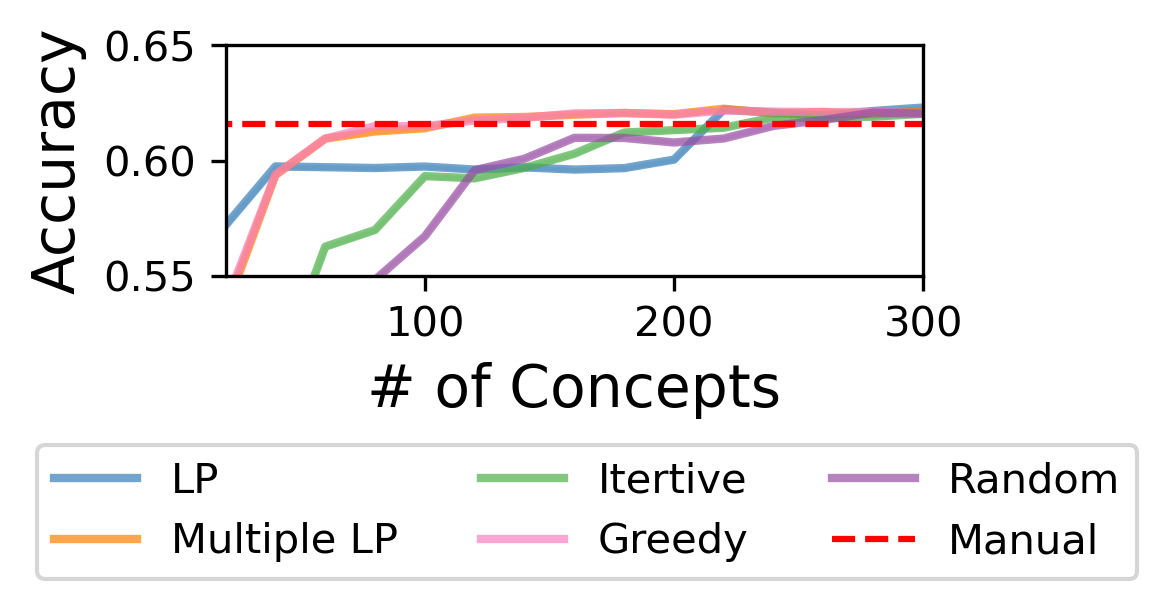

In [66]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,1),
    'style_size': style_size,
    'has_grid': False, 
    'x_lim': [[[20,300]]],
    # 'y_ticks': [[[[0.2,0.4,0.6],["20%","40%","60%"]]]],
    'y_lim': [[[0.55,0.65]]],
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts"]],y_labels=[["Accuracy"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Multiple LP","Itertive","Greedy","Random"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [imperfect_lp,multiple_lp,iterative_lp,greedy,random_selection]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
ax[0][0].hlines(chosen_concepts,0,311,label="Manual",color="red",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (-0.3,-1.4),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_cub.pdf",dpi=300, bbox_inches='tight')

In [64]:
similarity_multiple = [[len(set(m['imperfect']['multiple'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_random= [[len(set(m['imperfect']['random'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_greedy= [[len(set(m['imperfect']['greedy'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_iterative= [[len(set(m['imperfect']['iterative'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity = [[len(set(m['perfect']['lp'][str(c)]['concepts']).intersection(set(matching_params[0]['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]

similarity_multiple = np.mean(similarity_multiple,axis=1)
similarity_random = np.mean(similarity_random,axis=1)
similarity_greedy = np.mean(similarity_greedy,axis=1)
similarity_iterative = np.mean(similarity_iterative,axis=1)
similarity = np.mean(similarity,axis=1)

/tmp/ipykernel_3635104/4211550753.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


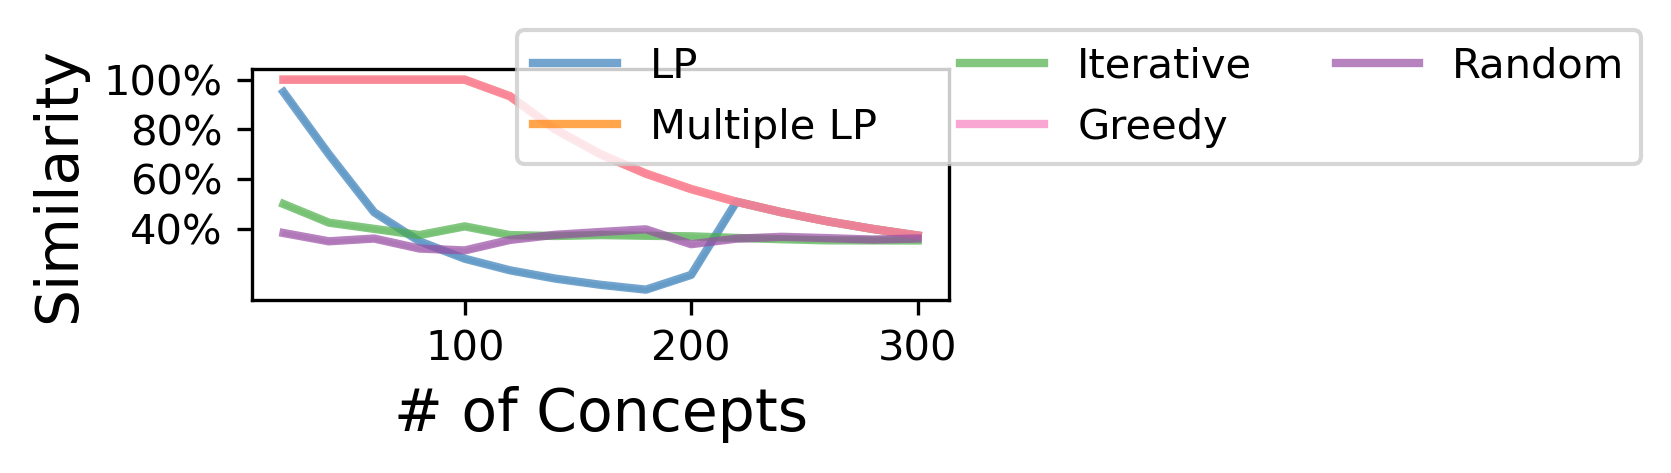

In [67]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,1),
    'style_size': style_size,
    'has_grid': False, 
    'y_ticks': [[[[0.4,0.6,0.8,1],["40%","60%","80%","100%"]]]],
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts"]],y_labels=[["Similarity"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Multiple LP","Iterative","Greedy","Random"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(similarity)-1)] for i in range(len(x_groups[0]))] for arr in [similarity,similarity_multiple,similarity_iterative,similarity_greedy,similarity_random]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0.35,0.5),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/similarity_cub.pdf",dpi=300, bbox_inches='tight')

In [84]:
imperfect_intervention = np.array([[m['intervention']['lp'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params])
imperfect_intervention = np.mean(imperfect_intervention,axis=0)
multiple_intervention = np.array([[m['intervention']['multiple'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params])
multiple_intervention = np.mean(multiple_intervention,axis=0)
iterative_intervention = np.array([[m['intervention']['iterative'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params])
iterative_intervention = np.mean(iterative_intervention,axis=0)
greedy_intervention = np.array([[m['intervention']['greedy'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params])
greedy_intervention = np.mean(greedy_intervention,axis=0)
random_intervention = np.array([[m['intervention']['random'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params])
random_intervention  = np.mean(random_intervention,axis=0)
chosen_concepts = np.array([[m['intervention']['manual'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params])
chosen_concepts = np.mean(chosen_concepts,axis=0)

/tmp/ipykernel_3635104/677348531.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


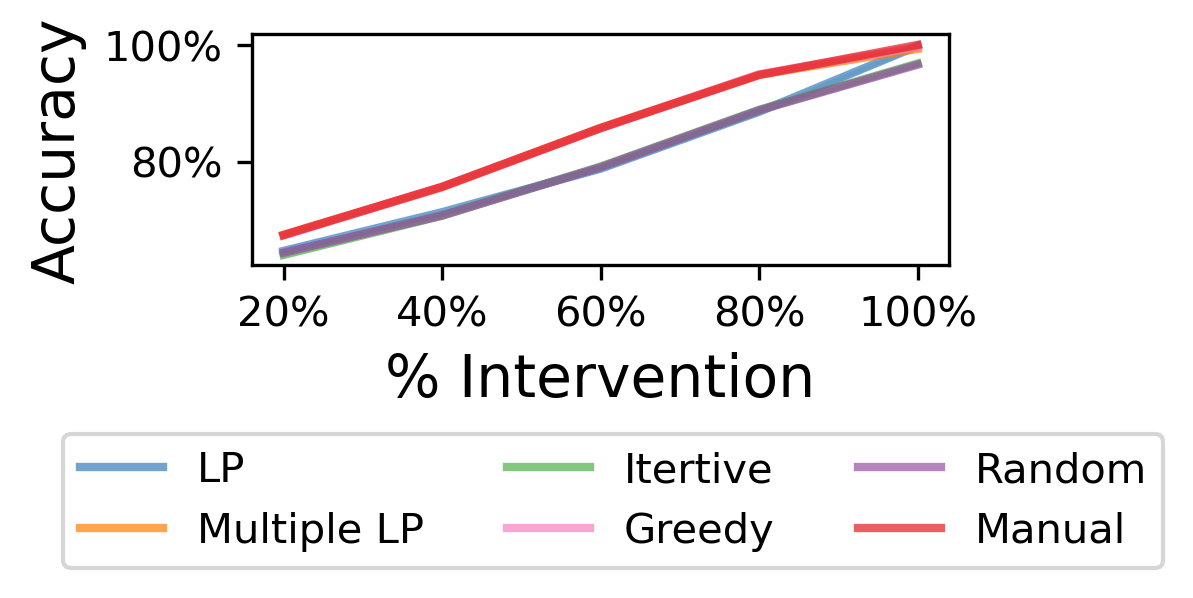

In [88]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,1),
    'style_size': style_size,
    'has_grid': False, 
    'y_ticks': [[[[0,0.2,0.4,0.6,0.8,1],["0%","20%","40%","60%","80%","100%"]]]],
    'x_ticks': [[[[0,0.2,0.4,0.6,0.8,1],["0%","20%","40%","60%","80%","100%"]]]]
    
    # 'y_lim': [[[0.55,0.65]]],
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["% Intervention"]],y_labels=[["Accuracy"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["LP","Multiple LP","Itertive","Greedy","Random","Manual"]

x_groups = [[0.2,0.4,0.6,0.8,1.0] for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [imperfect_intervention,multiple_intervention,iterative_intervention,greedy_intervention,random_intervention,chosen_concepts]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (-0.3,-1.4),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_cub.pdf",dpi=300, bbox_inches='tight')